<a href="https://colab.research.google.com/github/SZB08/Ques_logist/blob/my/ceshi_daima.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

📌 已加载固定最优超参数，开始执行最终 5 折 OOF 评估与 TreeSHAP 计算...

📊 最终定型 XGBoost 5-Fold OOF 完整评估报告
• ROC-AUC                  : 0.7841 (5-Fold Mean: 0.7841 ± 0.0023)
• PR-AUC (Precision-Recall) : 0.1267 (5-Fold Mean: 0.1273 ± 0.0029)
• Brier Score              : 0.1851 (5-Fold Mean: 0.1851 ± 0.0016)
• Precision @ 90% Recall   : 0.0501 (决策阈值 Cutoff = 0.2855)
• Precision @ 80% Recall   : 0.0666 (决策阈值 Cutoff = 0.4240)



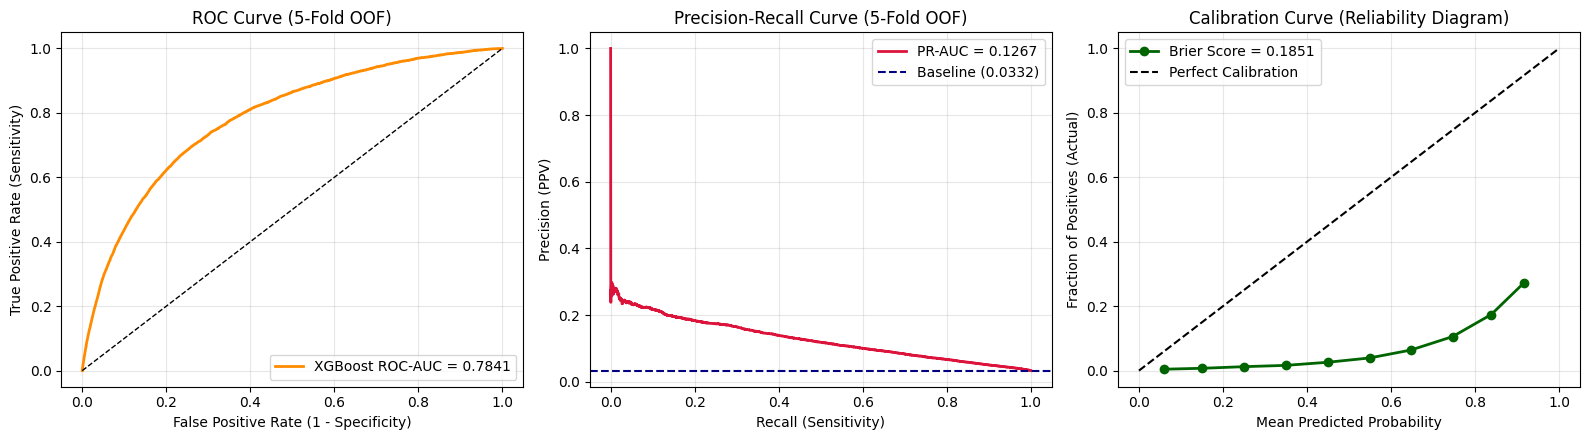

In [ ]:
# =============== 1. 基础库与预处理库 ===============
import pandas as pd
import numpy as np
import xgboost as xgb
import shap
import warnings
import matplotlib.pyplot as plt
import time  # <--- 确保导入了 time 模块
import os
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    roc_curve, auc, roc_auc_score,
    precision_recall_curve, average_precision_score,
    brier_score_loss, confusion_matrix
)
from sklearn.calibration import calibration_curve
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer
from xgboost import XGBClassifier

pd.set_option('display.float_format', '{:.10f}'.format)
warnings.filterwarnings("ignore")

# ================= 2. 数据加载与预处理 =================
FILE_PATH = '/content/drive/MyDrive/公开数据集/risk.txt'

usecols = [0, 1, 2, 3, 5, 6, 7, 8, 11, 12, 13]
names = ['menopause', 'age_5_years', 'BIRADS_breast_density', 'ethnic', 'bmi',
         'first_birth', 'num_of_first_degree_cancer', 'breast_surgery',
         'hormone_therapy', 'diagnosis_12', 'diagnosis_13']

try:
    data = pd.read_csv(FILE_PATH, sep=r'\s+', header=None, usecols=usecols, names=names)
except:
    print("⚠️ 未找到真实数据集，自动生成模拟数据用于测试代码逻辑...")
    np.random.seed(42)
    data = pd.DataFrame(np.random.randint(0, 5, size=(1000, len(names))), columns=names)
    data['diagnosis_12'] = np.random.randint(0, 2, 1000)
    data['diagnosis_13'] = np.random.randint(0, 2, 1000)

cols_with_missing_9 = ['menopause', 'BIRADS_breast_density', 'ethnic', 'bmi',
                       'first_birth', 'num_of_first_degree_cancer',
                       'breast_surgery', 'hormone_therapy']
for col in cols_with_missing_9:
    data[col] = data[col].replace(9, 'unknown').astype(str)
data['age_5_years'] = data['age_5_years'].astype(str)

data['diagnosis'] = (data['diagnosis_12'].astype(int) | data['diagnosis_13'].astype(int)).astype(int)
data = data.drop(columns=['diagnosis_12', 'diagnosis_13'])

X = data.drop(columns=['diagnosis'])
y = data['diagnosis']

ordered_features = ['age_5_years', 'BIRADS_breast_density', 'bmi', 'num_of_first_degree_cancer']
unordered_features = ['ethnic', 'first_birth', 'menopause', 'breast_surgery', 'hormone_therapy']
all_features = ordered_features + unordered_features

def get_categories(col_name, X_data):
    unique_vals = X_data[col_name].unique().tolist()
    known_order_map = {
        'age_5_years': [str(i) for i in range(1, 11)],
        'BIRADS_breast_density': ['1', '2', '3', '4'],
        'bmi': ['1', '2', '3', '4'],
        'num_of_first_degree_cancer': ['0', '1', '2']
    }
    known_order = known_order_map.get(col_name, [])
    final_order = [c for c in known_order if c in unique_vals]
    if 'unknown' in unique_vals and 'unknown' not in final_order:
        final_order.append('unknown')
    for val in unique_vals:
        if val not in final_order:
            final_order.append(val)
    return final_order

ordered_categories = [get_categories(f, X) for f in ordered_features]
unordered_levels = {
    'first_birth': ['0', '1', '2', 'unknown'],
    'ethnic':      ['1', '2', '3', '4', '5', 'unknown'],
    'menopause':   ['0', '1', 'unknown'],
    'breast_surgery': ['0', '1', 'unknown'],
    'hormone_therapy': ['0', '1', 'unknown']
}
unordered_categories = [unordered_levels[col] for col in unordered_features]

preprocessor_improved = ColumnTransformer(
    transformers=[
        ('ordered', OrdinalEncoder(categories=ordered_categories, handle_unknown='use_encoded_value', unknown_value=-1), ordered_features),
        ('unordered', OrdinalEncoder(categories=unordered_categories, handle_unknown='use_encoded_value', unknown_value=-1), unordered_features),
    ],
    remainder='passthrough'
)

# ==================================================================
# 3. 固定的 5 折最优超参数字典 (不再重复搜索)
# ==================================================================
FIXED_BEST_PARAMS = {
    'n_estimators': 150,
    'max_depth': 5,
    'learning_rate': 0.1,
    'subsample': 0.8,
    'colsample_bytree': 0.85,  #0.82
    'min_child_weight': 9,  #8
    'reg_alpha': 0.002,   #0.002
    'reg_lambda': 0.2,   #0.2
    'eval_metric': 'logloss',
    'random_state': 42,
    'n_jobs': -1
}

print("📌 已加载固定最优超参数，开始执行最终 5 折 OOF 评估与 TreeSHAP 计算...")

# ==================================================================
# 4. Stratified 5-Fold 评估循环 + OOF SHAP 收集
# ==================================================================
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 用于 OOF 评价指标的数组
oof_y_true = np.zeros(len(y))
oof_y_prob = np.zeros(len(y))

# 用于 TreeSHAP 的数组和全局编码 DataFrame
X_all_encoded = preprocessor_improved.fit_transform(X)
X_all_encoded_df = pd.DataFrame(X_all_encoded, columns=all_features)
oof_shap_values = np.zeros(X_all_encoded.shape)

fold_roc_aucs = []
fold_pr_aucs = []
fold_brier_scores = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_tr, y_tr = X.iloc[train_idx], y.iloc[train_idx]
    X_va, y_va = X.iloc[val_idx], y.iloc[val_idx]

    # 动态适配本折的类不平衡权重
    scale_pos_weight = (len(y_tr) - sum(y_tr)) / max(sum(y_tr), 1)
    current_params = FIXED_BEST_PARAMS.copy()
    current_params['scale_pos_weight'] = scale_pos_weight

    # 特征转换
    X_tr_enc = preprocessor_improved.fit_transform(X_tr)
    X_va_enc = preprocessor_improved.transform(X_va)

    # 训练模型
    model = XGBClassifier(**current_params)
    model.fit(X_tr_enc, y_tr)

    # 1) 预测袋外概率
    val_probs = model.predict_proba(X_va_enc)[:, 1]
    oof_y_true[val_idx] = y_va.values
    oof_y_prob[val_idx] = val_probs

    # 2) 计算袋外 TreeSHAP 值
    explainer = shap.TreeExplainer(model)
    oof_shap_values[val_idx] = explainer.shap_values(X_va_enc)

    # 记录本折指标
    fold_roc_aucs.append(roc_auc_score(y_va, val_probs))
    fold_pr_aucs.append(average_precision_score(y_va, val_probs))
    fold_brier_scores.append(brier_score_loss(y_va, val_probs))

# ==================================================================
# 5. 扩展指标汇总计算与报告打印
# ==================================================================
overall_roc_auc = roc_auc_score(oof_y_true, oof_y_prob)
overall_pr_auc = average_precision_score(oof_y_true, oof_y_prob)
overall_brier = brier_score_loss(oof_y_true, oof_y_prob)

precisions, recalls, pr_thresholds = precision_recall_curve(oof_y_true, oof_y_prob)

idx_90 = np.argmin(np.abs(recalls - 0.90))
prec_at_rec90 = precisions[idx_90]
thresh_at_rec90 = pr_thresholds[idx_90] if idx_90 < len(pr_thresholds) else 0.5

idx_80 = np.argmin(np.abs(recalls - 0.80))
prec_at_rec80 = precisions[idx_80]
thresh_at_rec80 = pr_thresholds[idx_80] if idx_80 < len(pr_thresholds) else 0.5

print("\n" + "="*65)
print("📊 最终定型 XGBoost 5-Fold OOF 完整评估报告")
print("="*65)
print(f"• ROC-AUC                  : {overall_roc_auc:.4f} (5-Fold Mean: {np.mean(fold_roc_aucs):.4f} ± {np.std(fold_roc_aucs):.4f})")
print(f"• PR-AUC (Precision-Recall) : {overall_pr_auc:.4f} (5-Fold Mean: {np.mean(fold_pr_aucs):.4f} ± {np.std(fold_pr_aucs):.4f})")
print(f"• Brier Score              : {overall_brier:.4f} (5-Fold Mean: {np.mean(fold_brier_scores):.4f} ± {np.std(fold_brier_scores):.4f})")
print(f"• Precision @ 90% Recall   : {prec_at_rec90:.4f} (决策阈值 Cutoff = {thresh_at_rec90:.4f})")
print(f"• Precision @ 80% Recall   : {prec_at_rec80:.4f} (决策阈值 Cutoff = {thresh_at_rec80:.4f})")
print("="*65 + "\n")

# ==================================================================
# 6. 三合一评估对比图 (ROC / PR / Calibration)
# ==================================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# ROC 曲线
fpr, tpr, _ = roc_curve(oof_y_true, oof_y_prob)
axes[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'XGBoost ROC-AUC = {overall_roc_auc:.4f}')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1)
axes[0].set_xlabel('False Positive Rate (1 - Specificity)')
axes[0].set_ylabel('True Positive Rate (Sensitivity)')
axes[0].set_title('ROC Curve (5-Fold OOF)')
axes[0].legend(loc="lower right")
axes[0].grid(True, alpha=0.3)

# PR 曲线
axes[1].plot(recalls, precisions, color='crimson', lw=2, label=f'PR-AUC = {overall_pr_auc:.4f}')
axes[1].axhline(y=np.mean(oof_y_true), color='navy', linestyle='--', label=f'Baseline ({np.mean(oof_y_true):.4f})')
axes[1].set_xlabel('Recall (Sensitivity)')
axes[1].set_ylabel('Precision (PPV)')
axes[1].set_title('Precision-Recall Curve (5-Fold OOF)')
axes[1].legend(loc="upper right")
axes[1].grid(True, alpha=0.3)

# 校准曲线
prob_true, prob_pred = calibration_curve(oof_y_true, oof_y_prob, n_bins=10, strategy='uniform')
axes[2].plot(prob_pred, prob_true, marker='o', linewidth=2, color='darkgreen', label=f'Brier Score = {overall_brier:.4f}')
axes[2].plot([0, 1], [0, 1], 'k--', label='Perfect Calibration')
axes[2].set_xlabel('Mean Predicted Probability')
axes[2].set_ylabel('Fraction of Positives (Actual)')
axes[2].set_title('Calibration Curve (Reliability Diagram)')
axes[2].legend(loc="upper left")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


🚀 开始拟合原生 XGBoost 模型...
模型训练成功，测试集 AUC = 0.7941


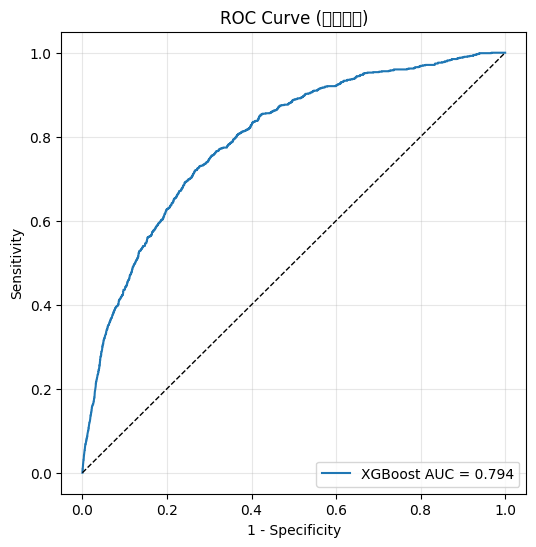


测试集分类报告（阈值=0.578）
              precision    recall  f1-score   support

           0       0.99      0.64      0.77     27136
           1       0.07      0.80      0.13       930

    accuracy                           0.64     28066
   macro avg       0.53      0.72      0.45     28066
weighted avg       0.96      0.64      0.75     28066

灵敏度 = 0.799，特异性 = 0.636

--- 5.1 TreeSHAP ---


 99%|===================| 495/500 [02:07<00:01]       

TreeSHAP 耗时: 127.77 s
                      Feature         tree
4                      ethnic 0.5993112100
1       BIRADS_breast_density 0.4464963900
3  num_of_first_degree_cancer 0.3965488100
0                 age_5_years 0.3778164700
2                         bmi 0.3325862400
5                 first_birth 0.3037350200
7              breast_surgery 0.2505724200
6                   menopause 0.1921904500
8             hormone_therapy 0.1845424700


In [ ]:
# =============== 1. 基础库与预处理库 ===============
import os
import time
from itertools import combinations
from math import factorial
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
from sklearn.compose import ColumnTransformer
from sklearn.inspection import PartialDependenceDisplay
from sklearn.metrics import (
    auc,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from tqdm import tqdm
import xgboost as xgb
from xgboost import XGBClassifier

pd.set_option('display.float_format', '{:.10f}'.format)

# ================= 2. 数据加载与编码 =================
FILE_PATH = '/content/drive/MyDrive/公开数据集/risk.txt'

usecols = [0, 1, 2, 3, 5, 6, 7, 8, 11, 12, 13]
names = [
    'menopause',
    'age_5_years',
    'BIRADS_breast_density',
    'ethnic',
    'bmi',
    'first_birth',
    'num_of_first_degree_cancer',
    'breast_surgery',
    'hormone_therapy',
    'diagnosis_12',
    'diagnosis_13',
]

try:
  data = pd.read_csv(
      FILE_PATH, sep=r'\s+', header=None, usecols=usecols, names=names
  )
except:
  print('⚠️ 未找到真实数据集，自动生成模拟数据用于测试代码逻辑...')
  np.random.seed(42)
  data = pd.DataFrame(
      np.random.randint(0, 5, size=(1000, len(names))), columns=names
  )
  data['diagnosis_12'] = np.random.randint(0, 2, 1000)
  data['diagnosis_13'] = np.random.randint(0, 2, 1000)

# 数据清洗和标签构造
cols_with_missing_9 = [
    'menopause',
    'BIRADS_breast_density',
    'ethnic',
    'bmi',
    'first_birth',
    'num_of_first_degree_cancer',
    'breast_surgery',
    'hormone_therapy',
]
for col in cols_with_missing_9:
  data[col] = data[col].replace(9, 'unknown').astype(str)
data['age_5_years'] = data['age_5_years'].astype(str)

data['diagnosis'] = (data['diagnosis_12'] | data['diagnosis_13']).astype(int)
data = data.drop(columns=['diagnosis_12', 'diagnosis_13'])

X = data.drop(columns=['diagnosis'])
y = data['diagnosis']

# 拆分数据 (8:1:1)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.1, stratify=y, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1111, stratify=y_temp, random_state=42
)

# 定义特征组
ordered_features = [
    'age_5_years',
    'BIRADS_breast_density',
    'bmi',
    'num_of_first_degree_cancer',
]
unordered_features = [
    'ethnic',
    'first_birth',
    'menopause',
    'breast_surgery',
    'hormone_therapy',
]
all_features = ordered_features + unordered_features


# 获取有序特征的类别顺序
def get_categories(col_name, X_train_data):
  unique_vals = X_train_data[col_name].unique().tolist()
  known_order_map = {
      'age_5_years': [str(i) for i in range(1, 11)],
      'BIRADS_breast_density': ['1', '2', '3', '4'],
      'bmi': ['1', '2', '3', '4'],
      'num_of_first_degree_cancer': ['0', '1', '2'],
  }

  known_order = known_order_map.get(col_name, [])
  final_order = [c for c in known_order if c in unique_vals]
  if 'unknown' in unique_vals and 'unknown' not in final_order:
    final_order.append('unknown')
  for val in unique_vals:
    if val not in final_order:
      final_order.append(val)
  return final_order


ordered_categories = [get_categories(f, X_train) for f in ordered_features]

unordered_levels = {
    'first_birth': ['0', '1', '2', 'unknown'],
    'ethnic': ['1', '2', '3', '4', '5', 'unknown'],
    'menopause': ['0', '1', 'unknown'],
    'breast_surgery': ['0', '1', 'unknown'],
    'hormone_therapy': ['0', '1', 'unknown'],
}
unordered_categories = [unordered_levels[col] for col in unordered_features]

preprocessor_improved = ColumnTransformer(
    transformers=[
        (
            'ordered',
            OrdinalEncoder(
                categories=ordered_categories,
                handle_unknown='use_encoded_value',
                unknown_value=-1,
            ),
            ordered_features,
        ),
        (
            'unordered',
            OrdinalEncoder(
                categories=unordered_categories,
                handle_unknown='use_encoded_value',
                unknown_value=-1,
            ),
            unordered_features,
        ),
    ],
    remainder='passthrough',
)

# 编码数据 (用于 SHAP 和预测)
X_train_encoded = preprocessor_improved.fit_transform(X_train)
X_val_encoded = preprocessor_improved.transform(X_val)
X_test_encoded = preprocessor_improved.transform(X_test)

X_train_encoded_df = pd.DataFrame(X_train_encoded, columns=all_features)
X_test_encoded_df = pd.DataFrame(X_test_encoded, columns=all_features)

# =============== 3. 原生 XGBoost 模型训练 (替换为指定超参数) =================
n_pos = y_train.sum()
n_neg = len(y_train) - n_pos
scale_pos_weight = max(n_neg / max(n_pos, 1), 50)

X_all_encoded = np.vstack([X_train_encoded, X_val_encoded])
y_all = np.hstack([y_train, y_val])

dtrain_all = xgb.DMatrix(X_all_encoded, label=y_all)
dtest = xgb.DMatrix(X_test_encoded, label=y_test)


# # 1. 定义手动平滑后的超参数 (注意原生接口的参数名)
# tuned_params = {
#     'max_depth': 5,
#     'eta': 0.1,                    # 对应 learning_rate: 0.1
#     'subsample': 0.8,              # 对应 subsample: 0.8
#     'colsample_bytree': 0.8,         # 对应 colsample_bytree: 1
#     'min_child_weight': 2,         # 对应 min_child_weight: 2
#     'alpha': 1,                # 对应 reg_alpha: 0.002
#     'lambda': 0.05                  # 对应 reg_lambda: 0.2
# }

# # 2. 合并固定参数 (必须包含 objective 和 scale_pos_weight)
# final_params = {
#     **tuned_params,
#     'objective': 'binary:logistic',
#     'eval_metric': 'logloss',      # 对应 eval_metric: 'logloss'
#     'scale_pos_weight': scale_pos_weight, # 针对类别不平衡的动态权重
#     'seed': 42,                    # 对应 random_state: 42
#     'nthread': -1,                 # 对应 n_jobs: -1
#     'base_score': 0.5
# }

# 1. 定义手动平滑后的超参数 (注意原生接口的参数名)
tuned_params = {
    'max_depth': 5,
    'eta': 0.1,                  # 原生接口使用 eta
    'subsample': 0.8,
    'colsample_bytree': 0.85,
    'min_child_weight': 9,
    'lambda': 0.2,               # 原生接口使用 lambda
    'alpha': 0.002                  # 原生接口使用 alpha
}

# 2. 合并固定参数 (必须包含 objective 和 scale_pos_weight)
final_params = {
    **tuned_params,
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'scale_pos_weight': scale_pos_weight, # 这一项对不平衡数据极其重要
    'seed': 42,
    'base_score': 0.5
}

print('🚀 开始拟合原生 XGBoost 模型...')
final_model = xgb.train(
    final_params,
    dtrain_all,
    num_boost_round=150,  # 对应 n_estimators: 150
    evals=[(dtest, 'test')],
    early_stopping_rounds=50,
    verbose_eval=False,
)

# 将训练好的 Booster 赋予 bst 供后续逻辑无缝使用
bst = final_model

best_ntree = (
    bst.best_iteration + 1
    if hasattr(bst, 'best_iteration') and bst.best_iteration is not None
    else 150
)
test_prob = bst.predict(dtest, iteration_range=(0, best_ntree))
test_auc = roc_auc_score(y_test, test_prob)
print(f'模型训练成功，测试集 AUC = {test_auc:.4f}')


# =============== 4. ROC 曲线与分类报告 =================
fpr, tpr, thresh = roc_curve(y_test, test_prob)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f'XGBoost AUC = {roc_auc:.3f}')
plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel('1 - Specificity')
plt.ylabel('Sensitivity')
plt.title('ROC Curve (原生模型)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

# Youden 选阈值
desired_sens = 0.8
idx = np.where(tpr >= desired_sens)[0][0]
best_thresh = thresh[idx]
test_pred = (test_prob > best_thresh).astype(int)

print('\n测试集分类报告（阈值={:.3f}）'.format(best_thresh))
print(classification_report(y_test, test_pred))

tn, fp, fn, tp = confusion_matrix(y_test, test_pred).ravel()
print(f'灵敏度 = {tp/(tp+fn):.3f}，特异性 = {tn/(tn+fp):.3f}')


# =============== 5. SHAP 核心设置与计算 =================
N_SHAP_SAMPLE = 500
X_100 = X_test_encoded_df.sample(N_SHAP_SAMPLE, random_state=123)

COMMON_BG = X_train_encoded_df.sample(3000, random_state=42)
COMMON_BG_1 = X_train_encoded_df.sample(3000, random_state=42)
bg_vals = COMMON_BG_1.values
features = all_features

def pred_fn(x):
  # base_margin / margin 预测，直接接受 NumPy 数组
  return bst.inplace_predict(x, predict_type='margin')
M = X.shape[1]  # 特征数
masker = shap.maskers.Independent(COMMON_BG, max_samples=len(COMMON_BG))
# ---- 5.1 TreeSHAP ----
print('\n--- 5.1 TreeSHAP ---')
explainer_t = shap.TreeExplainer(
    bst,
    data=masker,
    feature_perturbation='interventional',
    model_output='raw',  # 必须在 Log-odds 空间计算
)
start = time.time()
shap_tree = explainer_t.shap_values(
    X_100.astype(np.float32),
    tree_limit=best_ntree,
)
expected_val = explainer_t.expected_value

times = {'Tree': time.time() - start}
shapley_mat = {'Tree': shap_tree}

print(f'TreeSHAP 耗时: {times["Tree"]:.2f} s')

phi_tree = np.array(shapley_mat['Tree'])
mean_abs_tree = np.mean(np.abs(phi_tree), axis=0)
importance_df = pd.DataFrame({
    'Feature': all_features,  # 使用编码后的特征名
    #'Kernel_SHAP': mean_abs_kernel,
    #'k=2_Manual': mean_abs_kadd2,
    #'k=2_Manual_K1': mean_abs_kadd2k1,
    'tree': mean_abs_tree,
   # 'exact': mean_abs_exact,
    #'Diff': np.abs(mean_abs_kernel - mean_abs_kadd2)
}).sort_values('tree', ascending=False)

print(importance_df.round(8))


# 安全预测函数
def safe_pred_fn(x):
  if isinstance(x, np.ndarray):
    x = pd.DataFrame(x, columns=all_features)
  dm = xgb.DMatrix(x, feature_names=all_features)
  return bst.predict(dm, output_margin=True)


# ---- 5.2 KernelSHAP ----
print('\n--- 5.2 KernelSHAP ---')
start = time.time()
explainer_k = shap.KernelExplainer(safe_pred_fn, COMMON_BG)
shap_kernel_raw = explainer_k.shap_values(X_100, nsamples=512)

if isinstance(shap_kernel_raw, list):
  shapley_mat['Kernel'] = shap_kernel_raw[0]
else:
  shapley_mat['Kernel'] = shap_kernel_raw

times['Kernel'] = time.time() - start
print(f'KernelSHAP 耗时: {times["Kernel"]:.2f} s')


# ---- 5.3 Exact SHAP 函数定义与计算 ----
def exact_shap_one(xser):
  x = xser.values.astype(float)
  phis = np.zeros(M)
  for i in range(M):
    for size in range(0, M):
      for S in combinations([j for j in range(M) if j != i], size):
        S = list(S)
        weight = (
            factorial(len(S)) * factorial(M - len(S) - 1) / factorial(M)
        )

        X_S = bg_vals.copy()
        X_Si = bg_vals.copy()

        if S:
          X_S[:, S] = x[S]
          X_Si[:, S] = x[S]

        X_Si[:, i] = x[i]

        f_S = pred_fn(X_S).mean()
        f_Si = pred_fn(X_Si).mean()
        phis[i] += weight * (f_Si - f_S)
  return phis


print(f'\n--- 5.3 Exact SHAP ({N_SHAP_SAMPLE} 个样本, M={M}) ---')
if N_SHAP_SAMPLE * 2**M > 1e6:
  print('⚠️ 警告：Exact SHAP 计算量过大，已跳过。')
else:
  start = time.time()
  shapley_mat['Exact'] = np.array([
      exact_shap_one(X_100.iloc[i])
      for i in tqdm(range(len(X_100)), desc='Exact')
  ])
  times['Exact'] = time.time() - start
  print(f'Exact SHAP 耗时: {times["Exact"]:.2f} s')

# ---- 5.4 手写 k=2 SHAP 采样器 (Log-Odds) ----
print('\n--- 5.4 手写 k=2 SHAP 采样器 (Log-Odds) ---')
KADD_SAMPLES = 3000


def pred_fn_shapiq_safe(X_input: np.ndarray) -> np.ndarray:
  return bst.predict(xgb.DMatrix(X_input), output_margin=True)


def get_faithful_kadd_shap(phi_main, sii_matrix, total_delta):
  M_len = len(phi_main)
  phi_faithful = np.zeros(M_len)
  for i in range(M_len):
    phi_faithful[i] = phi_main[i] + 0.5 * np.sum(sii_matrix[i, :])
  current_sum = np.sum(phi_faithful)
  residual = total_delta - current_sum
  phi_faithful += residual / M_len
  return phi_faithful


bg_preds_global = safe_pred_fn(bg_vals)
expected_value = np.mean(bg_preds_global)
print(f'全局基准值 (Expected Value): {expected_value:.4f}')


def get_kadd_shap_k2_global(x_eval, bg_vals, samples):
  n_bg, M_len = bg_vals.shape
  phi_values = np.zeros(M_len)
  sii_matrix = np.zeros((M_len, M_len))

  rng = np.random.default_rng(seed=42)
  bg_indices = rng.integers(0, n_bg, size=samples)
  X_bg_batch = bg_vals[bg_indices]

  v_empty = np.mean(pred_fn_shapiq_safe(X_bg_batch))

  for i in range(M_len):
    X_i = X_bg_batch.copy()
    X_i[:, i] = x_eval[i]
    v_i = np.mean(pred_fn_shapiq_safe(X_i))
    phi_values[i] = v_i - v_empty

  for i in range(M_len):
    for j in range(i + 1, M_len):
      X_ij = X_bg_batch.copy()
      X_ij[:, i] = x_eval[i]
      X_ij[:, j] = x_eval[j]
      v_ij = np.mean(pred_fn_shapiq_safe(X_ij))

      v_i = phi_values[i] + v_empty
      X_j = X_bg_batch.copy()
      X_j[:, j] = x_eval[j]
      v_j = np.mean(pred_fn_shapiq_safe(X_j))

      sii_ij = v_ij - v_i - v_j + v_empty
      sii_matrix[i, j] = sii_ij
      sii_matrix[j, i] = sii_ij

  return phi_values, sii_matrix


faithful_phi_list = []
faithful_phi_list_K1 = []
start_time = time.time()
X_SHAP_SAMPLES_VALS = X_100.values

for i in tqdm(range(N_SHAP_SAMPLE), desc='k=2 SHAP 进度'):
  x_eval_single = X_SHAP_SAMPLES_VALS[i]
  phi, sii = get_kadd_shap_k2_global(x_eval_single, bg_vals, KADD_SAMPLES)
  current_pred = pred_fn_shapiq_safe(x_eval_single.reshape(1, -1))[0]
  total_delta = current_pred - expected_value

  phi_faithful = get_faithful_kadd_shap(phi, sii, total_delta)
  faithful_phi_list.append(phi_faithful)

  M_len = len(phi)
  sii_zero = np.zeros((M_len, M_len))
  phi_k1_faithful = get_faithful_kadd_shap(phi, sii_zero, total_delta)
  faithful_phi_list_K1.append(phi_k1_faithful)

times['KAdd2'] = time.time() - start_time
shapley_mat['KAdd2'] = np.array(faithful_phi_list)
shapley_mat['KAdd2K1'] = np.array(faithful_phi_list_K1)

# ==================================================================
# 6. 残差校准与诊断模块
# ==================================================================
def force_axiom_alignment(phi, expected_value, f_x):
  current_sums = np.sum(phi, axis=1)
  target_sums = f_x - expected_value
  gaps = target_sums - current_sums
  num_features = phi.shape[1]
  phi_corrected = phi + (gaps[:, np.newaxis] / num_features)
  return phi_corrected


dtest_encoded = xgb.DMatrix(X_100.astype(np.float32))
f_x_margin = bst.predict(
    dtest_encoded, iteration_range=(0, best_ntree), output_margin=True
)

shap_sum = np.sum(shap_tree, axis=1)
reconstructed_f_x = shap_sum + expected_val
residuals = f_x_margin - reconstructed_f_x

print(
    f'\n🔧 残差校验: 最大偏差 = {np.max(np.abs(residuals)):.6f}, 平均偏差 ='
    f' {np.mean(np.abs(residuals)):.6f}'
)

if np.max(np.abs(residuals)) > 1e-5:
  print('⚠️ 检测到残差偏差，正在执行公理化校准...')
  shap_tree = force_axiom_alignment(shap_tree, expected_val, f_x_margin)
  shapley_mat['Tree'] = shap_tree

# ==================================================================
# 7. 全局重要性对比与可视化
# ==================================================================
phi_kernel = np.array(shapley_mat['Kernel'])
phi_kadd2 = np.array(shapley_mat['KAdd2'])
phi_kadd2k1 = np.array(shapley_mat['KAdd2K1'])
phi_tree = np.array(shapley_mat['Tree'])
phi_exact = (
    np.array(shapley_mat['Exact']) if 'Exact' in shapley_mat else phi_tree
)

mae = np.mean(np.abs(phi_kernel - phi_kadd2))
correlation = np.corrcoef(phi_kernel.flatten(), phi_kadd2.flatten())[0, 1]
mean_abs_tree = np.mean(np.abs(phi_tree), axis=0)
importance_df = pd.DataFrame({
    'Feature': all_features,  # 使用编码后的特征名
    'Kernel_SHAP': mean_abs_kernel,
    'k=2_Manual': mean_abs_kadd2,
    'k=2_Manual_K1': mean_abs_kadd2k1,
    'tree': mean_abs_tree,
    'exact': mean_abs_exact,
    'Diff': np.abs(mean_abs_kernel - mean_abs_kadd2)
}).sort_values('tree', ascending=False)

print(importance_df.round(8))
print('\n📊 结果对比报告 (Kernel vs Custom k=2)')
print(f'k=2 手写耗时: {times["KAdd2"]:.2f} s')
print(f'与 Kernel 相关性: {correlation:.4f}')
print(f'MAE: {mae:.6f}')

plt.figure(figsize=(12, 6))
mean_abs_kernel = np.mean(np.abs(phi_kernel), axis=0)
mean_abs_kadd2 = np.mean(np.abs(phi_kadd2), axis=0)
x_pos = np.arange(len(all_features))

plt.bar(
    x_pos - 0.2,
    mean_abs_kernel,
    0.4,
    label='Kernel SHAP',
    alpha=0.8,
    color='steelblue',
)
plt.bar(
    x_pos + 0.2,
    mean_abs_kadd2,
    0.4,
    label='k=2 Manual',
    alpha=0.8,
    color='coral',
)
plt.xlabel('Features', fontsize=12)
plt.ylabel('Mean |SHAP Value|', fontsize=12)
plt.title('Global Feature Importance Comparison', fontsize=14)
plt.xticks(x_pos, all_features, rotation=45, ha='right')
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

# ==================================================================
# 8. 持久化保存至磁盘并简单校验
# ==================================================================
np.save('exact_shap.npy', np.array(shapley_mat['Exact']))
np.save('kernel_shap.npy', np.array(shapley_mat['Kernel']))
np.save('kadd2_shap.npy', np.array(shapley_mat['Tree']))
np.save('kadd2k1_shap.npy', np.array(shapley_mat['KAdd2']))

print('\n💾 SHAP计算结果已成功持久化保存为 .npy 文件！')

📊 全局特征重要性对比表 (按 Tree SHAP 排序):
                   Feature         Tree        Exact       Kernel        KAdd2      KAdd2K1
                    ethnic 0.5895844064 0.5895843870 0.5895843687 0.5799115490 0.5943895952
     BIRADS_breast_density 0.4218636657 0.4218636555 0.4218636425 0.4122525946 0.4343570671
               age_5_years 0.3962572113 0.3962572578 0.3962572450 0.4076865535 0.3930114864
num_of_first_degree_cancer 0.3679453531 0.3679453357 0.3679453272 0.3579669305 0.3844379116
                       bmi 0.3238566703 0.3238566581 0.3238566488 0.3204120026 0.3225541621
               first_birth 0.3047725177 0.3047725170 0.3047725078 0.2982511222 0.2483796538
            breast_surgery 0.2675246155 0.2675246276 0.2675246217 0.2533586865 0.2855938546
                 menopause 0.1857737084 0.1857737184 0.1857737126 0.1808344721 0.1761491824
           hormone_therapy 0.1572099899 0.1572099974 0.1572099912 0.1590005215 0.1256237657

📐 高精度误差比较报告 (相对于 Tree SHAP)
Kernel vs Tree  平均绝对

<Figure size 1200x600 with 0 Axes>

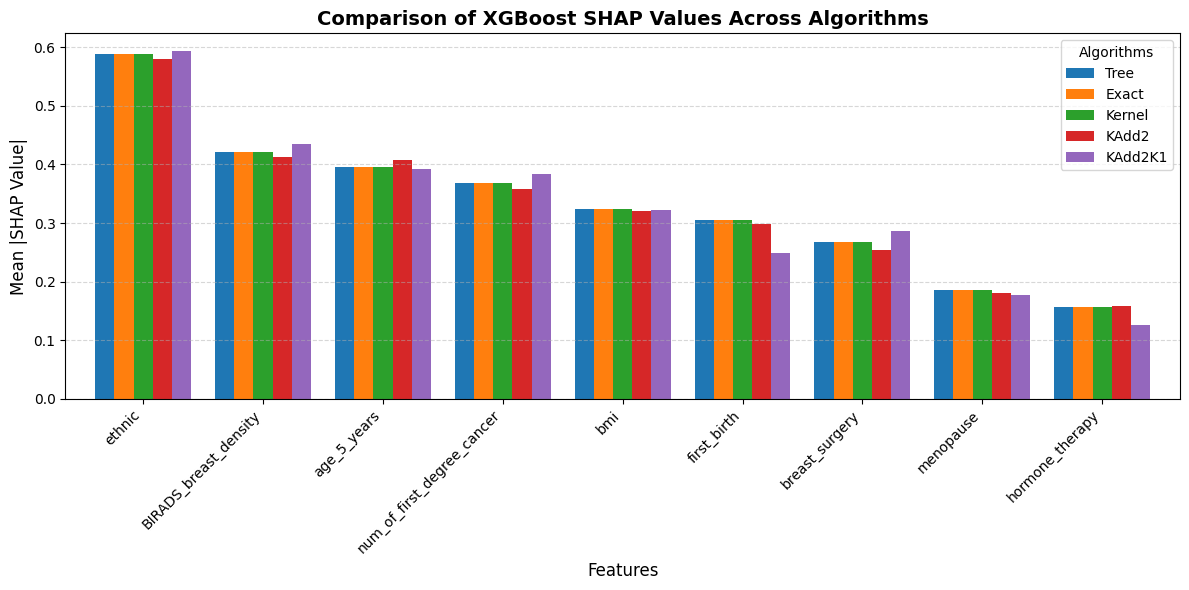

💡 提示: 未在云盘中找到 SII 矩阵文件 (XGBoost_5Fold_SII_Sample0.npy)。
   SII 属于样本级别的 2 阶交互矩阵 (9x9)，若需要在后期直接读取绘制，建议在生成 `sii_mat` 时补充一行 `np.save("SAVE_DIR/XGBoost_5Fold_SII_Sample0.npy", sii_0)` 保存。


In [ ]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# ==================================================================
# 1. 路径设置与特征名称定义
# ==================================================================
SAVE_DIR = '/content/drive/MyDrive/公开数据集/'

# 对应 XGBoost 预处理转换后的 9 个特征顺序
ordered_features = [
    'age_5_years',
    'BIRADS_breast_density',
    'bmi',
    'num_of_first_degree_cancer',
]
unordered_features = [
    'ethnic',
    'first_birth',
    'menopause',
    'breast_surgery',
    'hormone_therapy',
]
feature_names = ordered_features + unordered_features

# ==================================================================
# 2. 从云盘加载 .npy 文件
# ==================================================================
print('🚀 正在从云盘加载 XGBoost 多算法 SHAP 数组...')

exact_vals = np.load(
    os.path.join(SAVE_DIR, 'XGBoost_5Fold_Exact_SHAP_N500.npy')
)
kernel_vals = np.load(
    os.path.join(SAVE_DIR, 'XGBoost_5Fold_Kernel_SHAP_N500.npy')
)
k2_vals = np.load(os.path.join(SAVE_DIR, 'XGBoost_5Fold_KAdd2_SHAP_N500.npy'))
k1_vals = np.load(
    os.path.join(SAVE_DIR, 'XGBoost_5Fold_KAdd2K1_SHAP_N500.npy')
)
tree_vals = np.load(os.path.join(SAVE_DIR, 'XGBoost_5Fold_Tree_SHAP_N500.npy'))

print('✅ 所有 SHAP 数组加载成功！\n')

# ==================================================================
# 3. 构建全局特征重要性对比表 (Mean |SHAP|)
# ==================================================================
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Tree': np.abs(tree_vals).mean(axis=0),
    'Exact': np.abs(exact_vals).mean(axis=0),
    'Kernel': np.abs(kernel_vals).mean(axis=0),
    'KAdd2': np.abs(k2_vals).mean(axis=0),
    'KAdd2K1': np.abs(k1_vals).mean(axis=0),
}).sort_values('Tree', ascending=False)

with pd.option_context('display.float_format', '{:.10f}'.format):
  print('📊 全局特征重要性对比表 (按 Tree SHAP 排序):')
  print(importance_df.to_string(index=False))

# ==================================================================
# 4. 高精度误差分析 (以算法理论精确值 Tree/Exact 为基准)
# ==================================================================
diff_kernel = np.abs(kernel_vals - exact_vals)
diff_kadd2 = np.abs(k2_vals - exact_vals)
diff_tree = np.abs(tree_vals - exact_vals)

print('\n' + '=' * 50)
print('📐 高精度误差比较报告 (相对于 Tree SHAP)')
print('=' * 50)
print(f'Kernel vs Tree  平均绝对误差 (MAE): {np.mean(diff_kernel):.2e}')
print(f'KAdd2  vs Tree  平均绝对误差 (MAE): {np.mean(diff_kadd2):.2e}')
print(f'Exact  vs Tree  平均绝对误差 (MAE): {np.mean(diff_tree):.2e}')
print('=' * 50 + '\n')

# ==================================================================
# 5. 绘制多算法特征重要性对比图
# ==================================================================
plt.figure(figsize=(12, 6), dpi=100)
ax = importance_df.set_index('Feature').plot(
    kind='bar', figsize=(12, 6), width=0.8
)
plt.title(
    'Comparison of XGBoost SHAP Values Across Algorithms',
    fontsize=14,
    fontweight='bold',
)
plt.ylabel('Mean |SHAP Value|', fontsize=12)
plt.xlabel('Features', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(title='Algorithms', fontsize=10)
plt.tight_layout()
plt.show()

# ==================================================================
# 6. 读取与绘制 SII 交互矩阵热力图
# ==================================================================
sii_file = os.path.join(SAVE_DIR, 'XGBoost_5Fold_SII_Sample0.npy')

if os.path.exists(sii_file):
  sii_0 = np.load(sii_file)
  plt.figure(figsize=(8, 6), dpi=100)
  sns.heatmap(
      pd.DataFrame(sii_0, index=feature_names, columns=feature_names),
      annot=True,
      cmap='RdBu_r',
      center=0,
      fmt='.4f',
  )
  plt.title(
      'SII Interaction Matrix (Sample 0)', fontsize=12, fontweight='bold'
  )
  plt.tight_layout()
  plt.show()
else:
  print(
      '💡 提示: 未在云盘中找到 SII 矩阵文件 (XGBoost_5Fold_SII_Sample0.npy)。\n'
      '   SII 属于样本级别的 2 阶交互矩阵 (9x9)，若需要在后期直接读取绘制，'
      '建议在生成 `sii_mat` 时补充一行 `np.save("SAVE_DIR/XGBoost_5Fold_SII_Sample0.npy", sii_0)` 保存。'
  )

🔍 正在基于 Target Encoding 全对称特征网格调参...

📌 调优最佳 C 值 : 1.0
📌 5 折平均 ROC-AUC 得分 : 0.7425

📊 综合评估报告 (Stratified 5-Fold OOF)
• ROC-AUC                   : 0.7424 (5-Fold Mean: 0.7425 ± 0.0045)
• PR-AUC (Precision-Recall)  : 0.0917 (5-Fold Mean: 0.0922 ± 0.0025)
• Brier Score               : 0.2090 (5-Fold Mean: 0.2090 ± 0.0012)
• Precision at 90% Recall   : 0.0471 (Decision Threshold = 0.3274)
• Precision at 80% Recall   : 0.0571 (Decision Threshold = 0.4315)



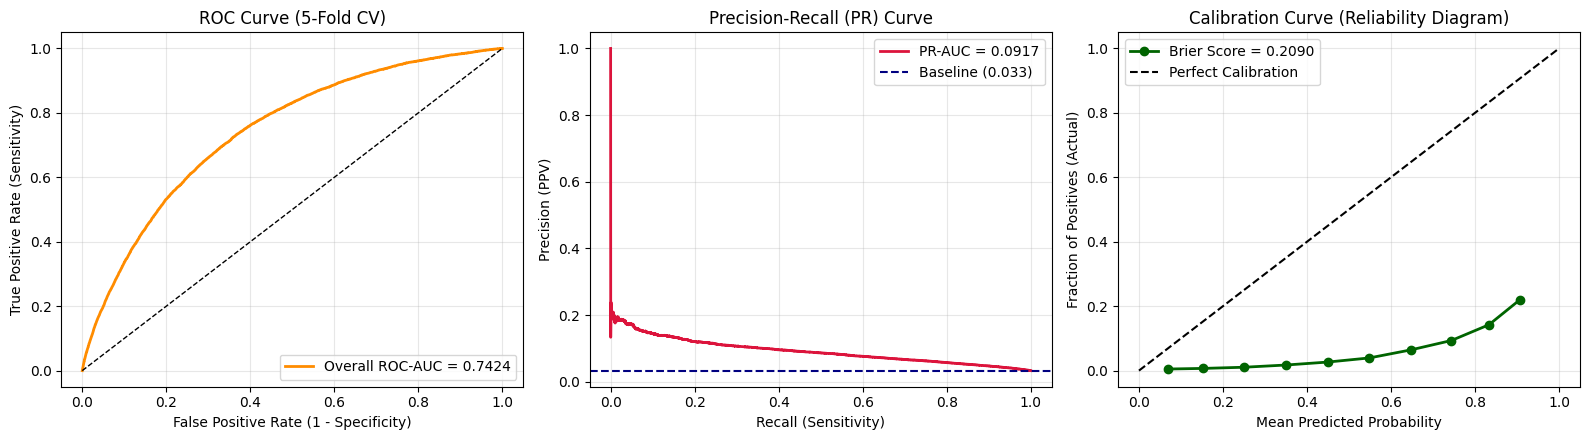


🚀 正在拟合 X_train 底座模型并构建 SHAP 环境...

🚀 开始传统循环版 Exact SHAP 计算 (N=500)...


  0%|          | 0/500 [00:00<?, ?it/s]

🚀 开始 Kernel SHAP 计算...


  0%|          | 0/500 [00:00<?, ?it/s]

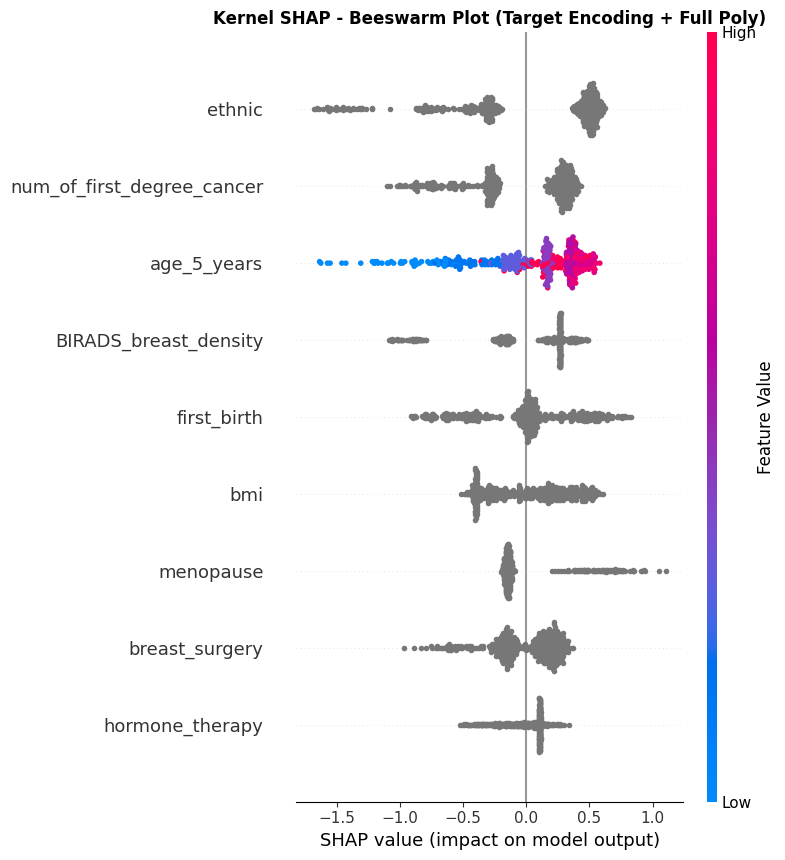

k-add SHAP 耗时: 115.45 s

K-ADDITIVE 误差溯源报告
残差/增量比: 0.00%

全局特征重要性对比表:
                   Feature        Exact       Kernel        KAdd2      KAdd2K1
                    ethnic 0.5461945169 0.5461945283 0.5461945169 0.5502263094
num_of_first_degree_cancer 0.3679771503 0.3679771389 0.3679771503 0.3663541987
               age_5_years 0.3599604291 0.3599604404 0.3599604291 0.3609301687
     BIRADS_breast_density 0.3273511239 0.3273511126 0.3273511239 0.3344155963
               first_birth 0.2906511562 0.2906511448 0.2906511562 0.2721094890
                       bmi 0.2829495969 0.2829495061 0.2829495969 0.2606499765
                 menopause 0.2305606986 0.2305607100 0.2305606986 0.2201237196
            breast_surgery 0.2142550223 0.2142550110 0.2142550223 0.2206999895
           hormone_therapy 0.1353337727 0.1353337841 0.1353337727 0.1206723973


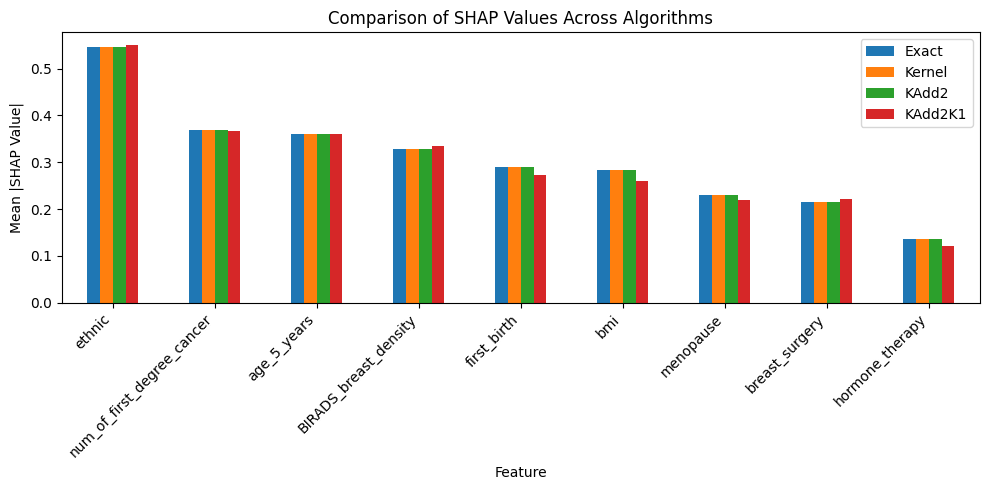

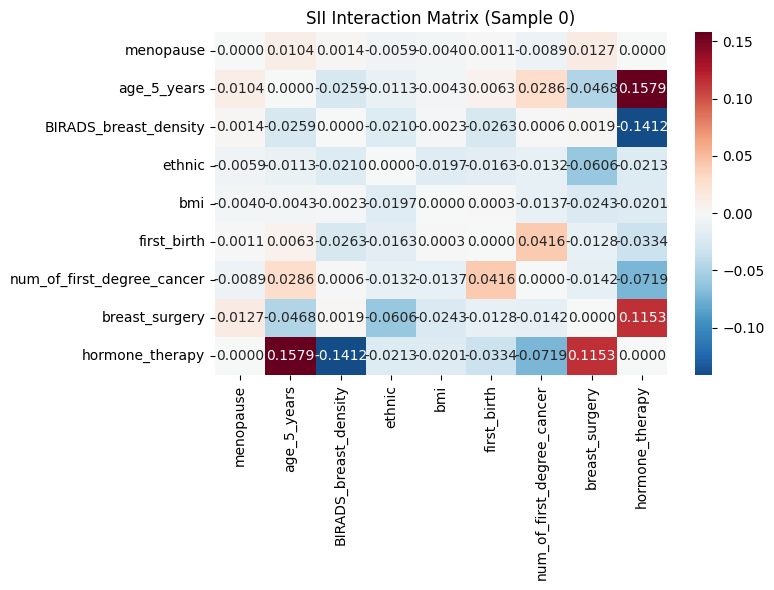


💾 已成功保存 SHAP 数据至 Google Drive:
  • Exact SHAP  : /content/drive/MyDrive/公开数据集/LogReg_5Fold_Exact_SHAP_N500.npy
  • Kernel SHAP : /content/drive/MyDrive/公开数据集/LogReg_5Fold_Kernel_SHAP_N500.npy
  • KAdd2 SHAP  : /content/drive/MyDrive/公开数据集/LogReg_5Fold_KAdd2_SHAP_N500.npy

高精度误差比较 (云盘重新载入检验)
Kernel vs Exact 最大差距: 4.54e-05
Kernel vs Exact 平均差距: 2.02e-08
KADD2 vs Exact  最大差距: 2.22e-15
KADD2 vs Exact  平均差距: 1.91e-16


In [ ]:
# =============== 1. 基础库与预处理库 ===============
import os
import time
import warnings
from itertools import combinations
from math import factorial

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
from sklearn.calibration import calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    auc,
    average_precision_score,
    brier_score_loss,
    precision_recall_curve,
    roc_curve,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    OrdinalEncoder,
    PolynomialFeatures,
    StandardScaler,
    TargetEncoder,
)
from tqdm.auto import tqdm

pd.set_option('display.float_format', '{:.10f}'.format)
warnings.filterwarnings('ignore')

# ==================================================================
# 1. 环境准备与数据加载
# ==================================================================
FILE_PATH = '/content/drive/MyDrive/公开数据集/risk.txt'
usecols = [0, 1, 2, 3, 5, 6, 7, 8, 11, 12, 13]
names = [
    'menopause',
    'age_5_years',
    'BIRADS_breast_density',
    'ethnic',
    'bmi',
    'first_birth',
    'num_of_first_degree_cancer',
    'breast_surgery',
    'hormone_therapy',
    'diagnosis_12',
    'diagnosis_13',
]

try:
  data = pd.read_csv(
      FILE_PATH, sep=r'\s+', header=None, usecols=usecols, names=names
  )
except:
  print('⚠️ 自动生成模拟数据用于环境运行...')
  np.random.seed(42)
  data = pd.DataFrame(
      np.random.randint(0, 5, size=(1000, len(names))), columns=names
  )
  data['diagnosis_12'] = np.random.randint(0, 2, 1000)
  data['diagnosis_13'] = np.random.randint(0, 2, 1000)

cols_with_missing_9 = [
    'menopause',
    'BIRADS_breast_density',
    'ethnic',
    'bmi',
    'first_birth',
    'num_of_first_degree_cancer',
    'breast_surgery',
    'hormone_therapy',
]
data_processed = data.copy()
for col in cols_with_missing_9:
  data_processed[col] = (
      data_processed[col].astype(str).replace('9', 'unknown').astype(str)
  )

data_processed['age_5_years'] = data_processed['age_5_years'].astype(str)
data_processed['diagnosis'] = (
    data_processed['diagnosis_12'] | data_processed['diagnosis_13']
).astype(int)
data_processed = data_processed.drop(columns=['diagnosis_12', 'diagnosis_13'])

X = data_processed.drop(columns=['diagnosis'])
y = data_processed['diagnosis']

feature_names = X.columns.tolist()
M = len(feature_names)  # 9

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.1, stratify=y, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1111, stratify=y_temp, random_state=42
)

# ==================================================================
# 2. 对称预处理：Target Encoding + Ordinal (所有特征保持 1 维)
# ==================================================================
ordered_features = [
    'age_5_years',
    'BIRADS_breast_density',
    'bmi',
    'num_of_first_degree_cancer',
]
unordered_features = ['ethnic', 'first_birth']
bin_features = ['menopause', 'breast_surgery', 'hormone_therapy']


def get_ordered_categories(col_name, X_data):
  unique_vals = X_data[col_name].unique().tolist()
  known_order_map = {
      'age_5_years': [str(i) for i in range(1, 11)],
      'BIRADS_breast_density': ['1', '2', '3', '4'],
      'bmi': ['1', '2', '3', '4'],
      'num_of_first_degree_cancer': ['0', '1', '2'],
  }
  known_order = known_order_map.get(col_name, [])
  final_order = [c for c in known_order if c in unique_vals]
  if 'unknown' in unique_vals and 'unknown' not in final_order:
    final_order.append('unknown')
  for val in unique_vals:
    if val not in final_order:
      final_order.append(val)
  return final_order


ordered_categories = [
    get_ordered_categories(f, X_train) for f in ordered_features
]

custom_levels = {
    'menopause': ['0', '1', 'unknown'],
    'breast_surgery': ['0', '1', 'unknown'],
    'hormone_therapy': ['0', '1', 'unknown'],
}
bin_categories = [custom_levels[col] for col in bin_features]

# 一级转换：所有特征转为 1 维连续/序号数值（共 9 列）
preprocessor_1d = ColumnTransformer([
    (
        'ord',
        OrdinalEncoder(
            categories=ordered_categories,
            handle_unknown='use_encoded_value',
            unknown_value=-1,
        ),
        ordered_features,
    ),
    (
        'target_enc',
        TargetEncoder(smooth='auto', cv=5, random_state=42),
        unordered_features,
    ),
    (
        'bin',
        OrdinalEncoder(
            categories=bin_categories,
            handle_unknown='use_encoded_value',
            unknown_value=-1,
        ),
        bin_features,
    ),
])

# 完整 Pipeline：1维降维 -> 9维全量2阶对称交互 -> 标准化 -> 逻辑回归
base_pipeline = Pipeline([
    ('prep', preprocessor_1d),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler()),
    (
        'logreg',
        LogisticRegression(
            max_iter=5000, class_weight='balanced', random_state=42
        ),
    ),
])

# ==================================================================
# 3. Stratified 5-Fold 评估与调参
# ==================================================================
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_grid = {'logreg__C': [0.01, 0.05, 0.1, 0.3, 0.5, 1.0, 5.0]}

print('🔍 正在基于 Target Encoding 全对称特征网格调参...')
grid_search = GridSearchCV(
    estimator=base_pipeline,
    param_grid=param_grid,
    cv=skf,
    scoring='roc_auc',
    n_jobs=-1,
)
grid_search.fit(X, y)

print('\n' + '=' * 50)
print(f"📌 调优最佳 C 值 : {grid_search.best_params_['logreg__C']}")
print(f'📌 5 折平均 ROC-AUC 得分 : {grid_search.best_score_:.4f}')
print('=' * 50 + '\n')

model_pipeline = grid_search.best_estimator_

# OOF 评估与性能绘图
oof_y_true = np.zeros(len(y))
oof_y_prob = np.zeros(len(y))
fold_roc_aucs, fold_pr_aucs, fold_brier_scores = [], [], []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
  X_tr, y_tr = X.iloc[train_idx], y.iloc[train_idx]
  X_va, y_va = X.iloc[val_idx], y.iloc[val_idx]

  model_pipeline.fit(X_tr, y_tr)
  val_probs = model_pipeline.predict_proba(X_va)[:, 1]

  oof_y_true[val_idx] = y_va.values
  oof_y_prob[val_idx] = val_probs

  fold_roc_aucs.append(auc(*roc_curve(y_va, val_probs)[:2]))
  fold_pr_aucs.append(average_precision_score(y_va, val_probs))
  fold_brier_scores.append(brier_score_loss(y_va, val_probs))

overall_roc_auc = auc(*roc_curve(oof_y_true, oof_y_prob)[:2])
overall_pr_auc = average_precision_score(oof_y_true, oof_y_prob)
overall_brier = brier_score_loss(oof_y_true, oof_y_prob)

precisions, recalls, thresholds = precision_recall_curve(oof_y_true, oof_y_prob)

idx_90 = np.argmin(np.abs(recalls - 0.90))
prec_at_rec90 = precisions[idx_90]
thresh_at_rec90 = thresholds[idx_90] if idx_90 < len(thresholds) else 0.5

idx_80 = np.argmin(np.abs(recalls - 0.80))
prec_at_rec80 = precisions[idx_80]
thresh_at_rec80 = thresholds[idx_80] if idx_80 < len(thresholds) else 0.5

print('📊 综合评估报告 (Stratified 5-Fold OOF)')
print('=' * 50)
print(
    f'• ROC-AUC                   : {overall_roc_auc:.4f} (5-Fold Mean:'
    f' {np.mean(fold_roc_aucs):.4f} ± {np.std(fold_roc_aucs):.4f})'
)
print(
    f'• PR-AUC (Precision-Recall)  : {overall_pr_auc:.4f} (5-Fold Mean:'
    f' {np.mean(fold_pr_aucs):.4f} ± {np.std(fold_pr_aucs):.4f})'
)
print(
    f'• Brier Score               : {overall_brier:.4f} (5-Fold Mean:'
    f' {np.mean(fold_brier_scores):.4f} ± {np.std(fold_brier_scores):.4f})'
)
print(
    f'• Precision at 90% Recall   : {prec_at_rec90:.4f} (Decision Threshold ='
    f' {thresh_at_rec90:.4f})'
)
print(
    f'• Precision at 80% Recall   : {prec_at_rec80:.4f} (Decision Threshold ='
    f' {thresh_at_rec80:.4f})'
)
print('=' * 50 + '\n')

# 绘制评估三合一图
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

fpr, tpr, _ = roc_curve(oof_y_true, oof_y_prob)
axes[0].plot(
    fpr,
    tpr,
    color='darkorange',
    lw=2,
    label=f'Overall ROC-AUC = {overall_roc_auc:.4f}',
)
axes[0].plot([0, 1], [0, 1], 'k--', lw=1)
axes[0].set_xlabel('False Positive Rate (1 - Specificity)')
axes[0].set_ylabel('True Positive Rate (Sensitivity)')
axes[0].set_title('ROC Curve (5-Fold CV)')
axes[0].legend(loc='lower right')
axes[0].grid(True, alpha=0.3)

axes[1].plot(
    recalls,
    precisions,
    color='crimson',
    lw=2,
    label=f'PR-AUC = {overall_pr_auc:.4f}',
)
baseline_ratio = np.mean(oof_y_true)
axes[1].axhline(
    y=baseline_ratio,
    color='navy',
    linestyle='--',
    label=f'Baseline ({baseline_ratio:.3f})',
)
axes[1].set_xlabel('Recall (Sensitivity)')
axes[1].set_ylabel('Precision (PPV)')
axes[1].set_title('Precision-Recall (PR) Curve')
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

prob_true, prob_pred = calibration_curve(
    oof_y_true, oof_y_prob, n_bins=10, strategy='uniform'
)
axes[2].plot(
    prob_pred,
    prob_true,
    marker='o',
    linewidth=2,
    color='darkgreen',
    label=f'Brier Score = {overall_brier:.4f}',
)
axes[2].plot([0, 1], [0, 1], 'k--', label='Perfect Calibration')
axes[2].set_xlabel('Mean Predicted Probability')
axes[2].set_ylabel('Fraction of Positives (Actual)')
axes[2].set_title('Calibration Curve (Reliability Diagram)')
axes[2].legend(loc='upper left')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ==================================================================
# 4. 拟合底座模型与正确构建 9 维 SHAP 环境 (解决 IndexError)
# ==================================================================
print('\n🚀 正在拟合 X_train 底座模型并构建 SHAP 环境...')
model_pipeline.fit(X_train, y_train)

prep = model_pipeline.named_steps['prep']

# 修正核心点：根据 preprocessor_1d 输出的 9 列正确建立索引映射 (0~8)
prep_feature_order = ordered_features + unordered_features + bin_features
feat_map = {}
for orig_idx, fname in enumerate(feature_names):
  prep_col_idx = prep_feature_order.index(fname)
  feat_map[orig_idx] = [prep_col_idx]


# 高速 Log-Odds 空间预测函数：输入 9 维矩阵，内部做 poly -> scaler -> logreg
def fast_pred(X_enc):
  X_poly = model_pipeline.named_steps['poly'].transform(X_enc)
  X_scaled = model_pipeline.named_steps['scaler'].transform(X_poly)
  return model_pipeline.named_steps['logreg'].decision_function(X_scaled)


# 样本与背景准备
N_SHAP_SAMPLE = 500
X_SHAP_SAMPLES = X_test.sample(
    n=min(N_SHAP_SAMPLE, len(X_test)), random_state=123
)
COMMON_BG = X_train.sample(n=min(3000, len(X_train)), random_state=42)

BG_ENC = prep.transform(COMMON_BG)
X_VAL_ENC = prep.transform(X_SHAP_SAMPLES)
expected_val = fast_pred(BG_ENC).mean()

# ==================================================================
# 5. 传统循环版 Exact SHAP (M=9)
# ==================================================================
def exact_shap_one_traditional(x_enc):
  phis = np.zeros(M)
  for i in range(M):
    for size in range(0, M):
      for S in combinations([j for j in range(M) if j != i], size):
        weight = (
            factorial(len(S))
            * factorial(M - len(S) - 1)
            / factorial(M)
        )

        X_S = BG_ENC.copy()
        X_Si = BG_ENC.copy()

        if S:
          for s_feat in S:
            cols = feat_map[s_feat]
            X_S[:, cols] = x_enc[cols]
            X_Si[:, cols] = x_enc[cols]

        i_cols = feat_map[i]
        X_Si[:, i_cols] = x_enc[i_cols]

        f_S = fast_pred(X_S).mean()
        f_Si = fast_pred(X_Si).mean()
        phis[i] += weight * (f_Si - f_S)
  return phis


print(
    f'\n🚀 开始传统循环版 Exact SHAP 计算 (N={len(X_SHAP_SAMPLES)})...'
)
start_time = time.time()
exact_vals = np.array([
    exact_shap_one_traditional(X_VAL_ENC[i])
    for i in tqdm(range(len(X_SHAP_SAMPLES)))
])
exact_duration = time.time() - start_time

# ==================================================================
# 6. Kernel SHAP 计算 (9 维黑盒)
# ==================================================================
def pred_kernel_fixed(X_in):
  if isinstance(X_in, np.ndarray):
    X_in = pd.DataFrame(X_in, columns=feature_names)
  return model_pipeline.decision_function(X_in)


BG_KERNEL = COMMON_BG.values
X_SHAP_KERNEL = X_SHAP_SAMPLES.values

print('🚀 开始 Kernel SHAP 计算...')
explainer_k = shap.KernelExplainer(pred_kernel_fixed, BG_KERNEL)
kernel_vals = explainer_k.shap_values(X_SHAP_KERNEL, nsamples=512, l1_reg=0)

# Kernel SHAP 蜂群图
explanation_kernel = shap.Explanation(
    values=kernel_vals,
    base_values=expected_val,
    data=X_SHAP_SAMPLES.values,
    feature_names=feature_names,
)

plt.figure(figsize=(10, 6), dpi=100)
shap.plots.beeswarm(
    explanation_kernel,
    max_display=M,
    plot_size=0.8,
    show=False,
    color_bar=True,
    color_bar_label='Feature Value',
)
plt.title(
    'Kernel SHAP - Beeswarm Plot (Target Encoding + Full Poly)',
    fontsize=12,
    fontweight='bold',
)
plt.tight_layout()
plt.show()

# ==================================================================
# 7. k-add (K2/K1) 手写计算与误差溯源
# ==================================================================
def get_kadd_manual(x_enc, bg_enc):
  phi_raw = np.zeros(M)
  sii_mat = np.zeros((M, M))
  v_empty = fast_pred(bg_enc).mean()

  for i in range(M):
    X_i = bg_enc.copy()
    X_i[:, feat_map[i]] = x_enc[feat_map[i]]
    phi_raw[i] = fast_pred(X_i).mean() - v_empty

  for i in range(M):
    for j in range(i + 1, M):
      X_ij = bg_enc.copy()
      for f in [i, j]:
        X_ij[:, feat_map[f]] = x_enc[feat_map[f]]
      v_ij = fast_pred(X_ij).mean()
      v_i = phi_raw[i] + v_empty
      X_j = bg_enc.copy()
      X_j[:, feat_map[j]] = x_enc[feat_map[j]]
      v_j = fast_pred(X_j).mean()
      sii_mat[i, j] = sii_mat[j, i] = v_ij - v_i - v_j + v_empty
  return phi_raw, sii_mat


def get_faithful_kadd_shap(phi, sii, delta):
  phi_f = phi + 0.5 * np.sum(sii, axis=1)
  return phi_f + (delta - np.sum(phi_f)) / M


start_kadd = time.time()
k2_list, k1_list, ana = [], [], []

for i in range(len(X_SHAP_SAMPLES)):
  phi, sii = get_kadd_manual(X_VAL_ENC[i], BG_ENC)
  delta = fast_pred(X_VAL_ENC[i : i + 1])[0] - expected_val
  k2_list.append(get_faithful_kadd_shap(phi, sii, delta))
  k1_list.append(get_faithful_kadd_shap(phi, np.zeros((M, M)), delta))
  ana.append({'td': delta, 'res': delta - (np.sum(phi) + 0.5 * np.sum(sii))})

kadd_duration = time.time() - start_kadd
print(f'k-add SHAP 耗时: {kadd_duration:.2f} s')

# ==================================================================
# 8. 报告与多算法对比
# ==================================================================
df_ana = pd.DataFrame(ana)
print('\n' + '=' * 50 + '\nK-ADDITIVE 误差溯源报告\n' + '=' * 50)
print(f"残差/增量比: {df_ana['res'].abs().mean() / df_ana['td'].abs().mean():.2%}")

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Exact': np.abs(exact_vals).mean(0),
    'Kernel': np.abs(kernel_vals).mean(0),
    'KAdd2': np.abs(np.array(k2_list)).mean(0),
    'KAdd2K1': np.abs(np.array(k1_list)).mean(0),
}).sort_values('Kernel', ascending=False)

with pd.option_context('display.float_format', '{:.10f}'.format):
  print('\n全局特征重要性对比表:')
  print(importance_df.to_string(index=False))

# 可视化对比图
importance_df.set_index('Feature').plot(kind='bar', figsize=(10, 5))
plt.title('Comparison of SHAP Values Across Algorithms')
plt.ylabel('Mean |SHAP Value|')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 样本 0 的 SII 交互矩阵热力图
sii_0 = get_kadd_manual(X_VAL_ENC[0], BG_ENC)[1]
plt.figure(figsize=(8, 6))
sns.heatmap(
    pd.DataFrame(sii_0, index=feature_names, columns=feature_names),
    annot=True,
    cmap='RdBu_r',
    center=0,
    fmt='.4f',
)
plt.title('SII Interaction Matrix (Sample 0)')
plt.tight_layout()
plt.show()

# ==================================================================
# 9. 持久化保存至 Google Drive 与高精度对比
# ==================================================================
SAVE_DIR = '/content/drive/MyDrive/公开数据集/'
os.makedirs(SAVE_DIR, exist_ok=True)

MODEL_PREFIX = 'LogReg_5Fold'
SAMPLE_TAG = f'N{len(X_SHAP_SAMPLES)}'

exact_fname = f'{MODEL_PREFIX}_Exact_SHAP_{SAMPLE_TAG}.npy'
kernel_fname = f'{MODEL_PREFIX}_Kernel_SHAP_{SAMPLE_TAG}.npy'
kadd2_fname = f'{MODEL_PREFIX}_KAdd2_SHAP_{SAMPLE_TAG}.npy'

exact_path = os.path.join(SAVE_DIR, exact_fname)
kernel_path = os.path.join(SAVE_DIR, kernel_fname)
kadd2_path = os.path.join(SAVE_DIR, kadd2_fname)

np.save(exact_path, exact_vals)
np.save(kernel_path, kernel_vals)
np.save(kadd2_path, np.array(k2_list))

print('\n' + '=' * 50)
print('💾 已成功保存 SHAP 数据至 Google Drive:')
print(f'  • Exact SHAP  : {exact_path}')
print(f'  • Kernel SHAP : {kernel_path}')
print(f'  • KAdd2 SHAP  : {kadd2_path}')

exact_loaded = np.load(exact_path)
kernel_loaded = np.load(kernel_path)
KADD_loaded = np.load(kadd2_path)

diff = np.abs(exact_loaded - kernel_loaded)
diff_kadd = np.abs(exact_loaded - KADD_loaded)

print('\n' + '=' * 50)
print('高精度误差比较 (云盘重新载入检验)')
print('=' * 50)
print(f'Kernel vs Exact 最大差距: {np.max(diff):.2e}')
print(f'Kernel vs Exact 平均差距: {np.mean(diff):.2e}')
print(f'KADD2 vs Exact  最大差距: {np.max(diff_kadd):.2e}')
print(f'KADD2 vs Exact  平均差距: {np.mean(diff_kadd):.2e}')

In [ ]:
# =============== 1. 基础库与预处理库 ===============
import os
import time
import warnings
from itertools import combinations
from math import factorial

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
from sklearn.calibration import calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    auc,
    average_precision_score,
    brier_score_loss,
    precision_recall_curve,
    roc_curve,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    OrdinalEncoder,
    PolynomialFeatures,
    StandardScaler,
    TargetEncoder,
)
from tqdm.auto import tqdm

pd.set_option('display.float_format', '{:.10f}'.format)
warnings.filterwarnings('ignore')

# ==================================================================
# 1. 环境准备与数据加载
# ==================================================================
FILE_PATH = '/content/drive/MyDrive/公开数据集/risk.txt'
usecols = [0, 1, 2, 3, 5, 6, 7, 8, 11, 12, 13]
names = [
    'menopause',
    'age_5_years',
    'BIRADS_breast_density',
    'ethnic',
    'bmi',
    'first_birth',
    'num_of_first_degree_cancer',
    'breast_surgery',
    'hormone_therapy',
    'diagnosis_12',
    'diagnosis_13',
]

try:
  data = pd.read_csv(
      FILE_PATH, sep=r'\s+', header=None, usecols=usecols, names=names
  )
except:
  print('⚠️ 自动生成模拟数据用于环境运行...')
  np.random.seed(42)
  data = pd.DataFrame(
      np.random.randint(0, 5, size=(1000, len(names))), columns=names
  )
  data['diagnosis_12'] = np.random.randint(0, 2, 1000)
  data['diagnosis_13'] = np.random.randint(0, 2, 1000)

cols_with_missing_9 = [
    'menopause',
    'BIRADS_breast_density',
    'ethnic',
    'bmi',
    'first_birth',
    'num_of_first_degree_cancer',
    'breast_surgery',
    'hormone_therapy',
]
data_processed = data.copy()
for col in cols_with_missing_9:
  data_processed[col] = (
      data_processed[col].astype(str).replace('9', 'unknown').astype(str)
  )

data_processed['age_5_years'] = data_processed['age_5_years'].astype(str)
data_processed['diagnosis'] = (
    data_processed['diagnosis_12'] | data_processed['diagnosis_13']
).astype(int)
data_processed = data_processed.drop(columns=['diagnosis_12', 'diagnosis_13'])

X = data_processed.drop(columns=['diagnosis'])
y = data_processed['diagnosis']

feature_names = X.columns.tolist()
M = len(feature_names)  # 9

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.1, stratify=y, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1111, stratify=y_temp, random_state=42
)

# ==================================================================
# 2. 对称预处理：Target Encoding + Ordinal (所有特征保持 1 维)
# ==================================================================
ordered_features = [
    'age_5_years',
    'BIRADS_breast_density',
    'bmi',
    'num_of_first_degree_cancer',
]
unordered_features = ['ethnic', 'first_birth']
bin_features = ['menopause', 'breast_surgery', 'hormone_therapy']


def get_ordered_categories(col_name, X_data):
  unique_vals = X_data[col_name].unique().tolist()
  known_order_map = {
      'age_5_years': [str(i) for i in range(1, 11)],
      'BIRADS_breast_density': ['1', '2', '3', '4'],
      'bmi': ['1', '2', '3', '4'],
      'num_of_first_degree_cancer': ['0', '1', '2'],
  }
  known_order = known_order_map.get(col_name, [])
  final_order = [c for c in known_order if c in unique_vals]
  if 'unknown' in unique_vals and 'unknown' not in final_order:
    final_order.append('unknown')
  for val in unique_vals:
    if val not in final_order:
      final_order.append(val)
  return final_order


ordered_categories = [
    get_ordered_categories(f, X_train) for f in ordered_features
]

custom_levels = {
    'menopause': ['0', '1', 'unknown'],
    'breast_surgery': ['0', '1', 'unknown'],
    'hormone_therapy': ['0', '1', 'unknown'],
}
bin_categories = [custom_levels[col] for col in bin_features]

# 一级转换：所有特征转为 1 维连续/序号数值（共 9 列）
preprocessor_1d = ColumnTransformer([
    (
        'ord',
        OrdinalEncoder(
            categories=ordered_categories,
            handle_unknown='use_encoded_value',
            unknown_value=-1,
        ),
        ordered_features,
    ),
    (
        'target_enc',
        TargetEncoder(smooth='auto', cv=5, random_state=42),
        unordered_features,
    ),
    (
        'bin',
        OrdinalEncoder(
            categories=bin_categories,
            handle_unknown='use_encoded_value',
            unknown_value=-1,
        ),
        bin_features,
    ),
])

# 完整 Pipeline：1维降维 -> 9维全量2阶对称交互 -> 标准化 -> 逻辑回归
base_pipeline = Pipeline([
    ('prep', preprocessor_1d),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler()),
    (
        'logreg',
        LogisticRegression(
            max_iter=5000, class_weight='balanced', random_state=42
        ),
    ),
])

# ==================================================================
# 3. Stratified 5-Fold 评估与调参
# ==================================================================
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_grid = {'logreg__C': [1]}

print('🔍 正在基于 Target Encoding 全对称特征网格调参...')
grid_search = GridSearchCV(
    estimator=base_pipeline,
    param_grid=param_grid,
    cv=skf,
    scoring='roc_auc',
    n_jobs=-1,
)
grid_search.fit(X, y)

print('\n' + '=' * 50)
print(f"📌 调优最佳 C 值 : {grid_search.best_params_['logreg__C']}")
print(f'📌 5 折平均 ROC-AUC 得分 : {grid_search.best_score_:.4f}')
print('=' * 50 + '\n')

model_pipeline = grid_search.best_estimator_

# OOF 评估与性能绘图
oof_y_true = np.zeros(len(y))
oof_y_prob = np.zeros(len(y))
fold_roc_aucs, fold_pr_aucs, fold_brier_scores = [], [], []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
  X_tr, y_tr = X.iloc[train_idx], y.iloc[train_idx]
  X_va, y_va = X.iloc[val_idx], y.iloc[val_idx]

  model_pipeline.fit(X_tr, y_tr)
  val_probs = model_pipeline.predict_proba(X_va)[:, 1]

  oof_y_true[val_idx] = y_va.values
  oof_y_prob[val_idx] = val_probs

  fold_roc_aucs.append(auc(*roc_curve(y_va, val_probs)[:2]))
  fold_pr_aucs.append(average_precision_score(y_va, val_probs))
  fold_brier_scores.append(brier_score_loss(y_va, val_probs))

overall_roc_auc = auc(*roc_curve(oof_y_true, oof_y_prob)[:2])
overall_pr_auc = average_precision_score(oof_y_true, oof_y_prob)
overall_brier = brier_score_loss(oof_y_true, oof_y_prob)

precisions, recalls, thresholds = precision_recall_curve(oof_y_true, oof_y_prob)

idx_90 = np.argmin(np.abs(recalls - 0.90))
prec_at_rec90 = precisions[idx_90]
thresh_at_rec90 = thresholds[idx_90] if idx_90 < len(thresholds) else 0.5

idx_80 = np.argmin(np.abs(recalls - 0.80))
prec_at_rec80 = precisions[idx_80]
thresh_at_rec80 = thresholds[idx_80] if idx_80 < len(thresholds) else 0.5

print('📊 综合评估报告 (Stratified 5-Fold OOF)')
print('=' * 50)
print(
    f'• ROC-AUC                   : {overall_roc_auc:.4f} (5-Fold Mean:'
    f' {np.mean(fold_roc_aucs):.4f} ± {np.std(fold_roc_aucs):.4f})'
)
print(
    f'• PR-AUC (Precision-Recall)  : {overall_pr_auc:.4f} (5-Fold Mean:'
    f' {np.mean(fold_pr_aucs):.4f} ± {np.std(fold_pr_aucs):.4f})'
)
print(
    f'• Brier Score               : {overall_brier:.4f} (5-Fold Mean:'
    f' {np.mean(fold_brier_scores):.4f} ± {np.std(fold_brier_scores):.4f})'
)
print(
    f'• Precision at 90% Recall   : {prec_at_rec90:.4f} (Decision Threshold ='
    f' {thresh_at_rec90:.4f})'
)
print(
    f'• Precision at 80% Recall   : {prec_at_rec80:.4f} (Decision Threshold ='
    f' {thresh_at_rec80:.4f})'
)
print('=' * 50 + '\n')

# 绘制评估三合一图
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

fpr, tpr, _ = roc_curve(oof_y_true, oof_y_prob)
axes[0].plot(
    fpr,
    tpr,
    color='darkorange',
    lw=2,
    label=f'Overall ROC-AUC = {overall_roc_auc:.4f}',
)
axes[0].plot([0, 1], [0, 1], 'k--', lw=1)
axes[0].set_xlabel('False Positive Rate (1 - Specificity)')
axes[0].set_ylabel('True Positive Rate (Sensitivity)')
axes[0].set_title('ROC Curve (5-Fold CV)')
axes[0].legend(loc='lower right')
axes[0].grid(True, alpha=0.3)

axes[1].plot(
    recalls,
    precisions,
    color='crimson',
    lw=2,
    label=f'PR-AUC = {overall_pr_auc:.4f}',
)
baseline_ratio = np.mean(oof_y_true)
axes[1].axhline(
    y=baseline_ratio,
    color='navy',
    linestyle='--',
    label=f'Baseline ({baseline_ratio:.3f})',
)
axes[1].set_xlabel('Recall (Sensitivity)')
axes[1].set_ylabel('Precision (PPV)')
axes[1].set_title('Precision-Recall (PR) Curve')
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

prob_true, prob_pred = calibration_curve(
    oof_y_true, oof_y_prob, n_bins=10, strategy='uniform'
)
axes[2].plot(
    prob_pred,
    prob_true,
    marker='o',
    linewidth=2,
    color='darkgreen',
    label=f'Brier Score = {overall_brier:.4f}',
)
axes[2].plot([0, 1], [0, 1], 'k--', label='Perfect Calibration')
axes[2].set_xlabel('Mean Predicted Probability')
axes[2].set_ylabel('Fraction of Positives (Actual)')
axes[2].set_title('Calibration Curve (Reliability Diagram)')
axes[2].legend(loc='upper left')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ==================================================================
# 4. 拟合底座模型与正确构建 9 维 SHAP 环境 (解决 IndexError)
# ==================================================================
print('\n🚀 正在拟合 X_train 底座模型并构建 SHAP 环境...')
model_pipeline.fit(X_train, y_train)

prep = model_pipeline.named_steps['prep']

# 修正核心点：根据 preprocessor_1d 输出的 9 列正确建立索引映射 (0~8)
prep_feature_order = ordered_features + unordered_features + bin_features
feat_map = {}
for orig_idx, fname in enumerate(feature_names):
  prep_col_idx = prep_feature_order.index(fname)
  feat_map[orig_idx] = [prep_col_idx]


# 高速 Log-Odds 空间预测函数：输入 9 维矩阵，内部做 poly -> scaler -> logreg
def fast_pred(X_enc):
  X_poly = model_pipeline.named_steps['poly'].transform(X_enc)
  X_scaled = model_pipeline.named_steps['scaler'].transform(X_poly)
  return model_pipeline.named_steps['logreg'].decision_function(X_scaled)


# 样本与背景准备
N_SHAP_SAMPLE = 500
X_SHAP_SAMPLES = X_test.sample(
    n=min(N_SHAP_SAMPLE, len(X_test)), random_state=123
)
COMMON_BG = X_train.sample(n=min(3000, len(X_train)), random_state=42)

BG_ENC = prep.transform(COMMON_BG)
X_VAL_ENC = prep.transform(X_SHAP_SAMPLES)
expected_val = fast_pred(BG_ENC).mean()

# ==================================================================
# 5. 传统循环版 Exact SHAP (M=9)
# ==================================================================
def exact_shap_one_traditional(x_enc):
  phis = np.zeros(M)
  for i in range(M):
    for size in range(0, M):
      for S in combinations([j for j in range(M) if j != i], size):
        weight = (
            factorial(len(S))
            * factorial(M - len(S) - 1)
            / factorial(M)
        )

        X_S = BG_ENC.copy()
        X_Si = BG_ENC.copy()

        if S:
          for s_feat in S:
            cols = feat_map[s_feat]
            X_S[:, cols] = x_enc[cols]
            X_Si[:, cols] = x_enc[cols]

        i_cols = feat_map[i]
        X_Si[:, i_cols] = x_enc[i_cols]

        f_S = fast_pred(X_S).mean()
        f_Si = fast_pred(X_Si).mean()
        phis[i] += weight * (f_Si - f_S)
  return phis


print(
    f'\n🚀 开始传统循环版 Exact SHAP 计算 (N={len(X_SHAP_SAMPLES)})...'
)
start_time = time.time()
exact_vals = np.array([
    exact_shap_one_traditional(X_VAL_ENC[i])
    for i in tqdm(range(len(X_SHAP_SAMPLES)))
])
exact_duration = time.time() - start_time

# ==================================================================
# 6. Kernel SHAP 计算 (9 维黑盒)
# ==================================================================
def pred_kernel_fixed(X_in):
  if isinstance(X_in, np.ndarray):
    X_in = pd.DataFrame(X_in, columns=feature_names)
  return model_pipeline.decision_function(X_in)


BG_KERNEL = COMMON_BG.values
X_SHAP_KERNEL = X_SHAP_SAMPLES.values

print('🚀 开始 Kernel SHAP 计算...')
explainer_k = shap.KernelExplainer(pred_kernel_fixed, BG_KERNEL)
kernel_vals = explainer_k.shap_values(X_SHAP_KERNEL, nsamples=512, l1_reg=0)

# Kernel SHAP 蜂群图
explanation_kernel = shap.Explanation(
    values=kernel_vals,
    base_values=expected_val,
    data=X_SHAP_SAMPLES.values,
    feature_names=feature_names,
)

plt.figure(figsize=(10, 6), dpi=100)
shap.plots.beeswarm(
    explanation_kernel,
    max_display=M,
    plot_size=0.8,
    show=False,
    color_bar=True,
    color_bar_label='Feature Value',
)
plt.title(
    'Kernel SHAP - Beeswarm Plot (Target Encoding + Full Poly)',
    fontsize=12,
    fontweight='bold',
)
plt.tight_layout()
plt.show()

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Kernel': np.abs(kernel_vals).mean(0)
}).sort_values('Kernel', ascending=False)

print('\n' + '=' * 50)
print('全局特征重要性表 (Kernel SHAP):')
print('=' * 50)
with pd.option_context('display.float_format', '{:.10f}'.format):
    print(importance_df.to_string(index=False))
print('=' * 50)


SAVE_DIR = '/content/drive/MyDrive/公开数据集/'

MODEL_PREFIX = 'LogReg_5Fold'
SAMPLE_TAG = f'N{len(X_SHAP_SAMPLES)}'

exact_path = os.path.join(SAVE_DIR, f'{MODEL_PREFIX}_Exact_SHAP_{SAMPLE_TAG}.npy')
kadd2_path = os.path.join(SAVE_DIR, f'{MODEL_PREFIX}_KAdd2_SHAP_{SAMPLE_TAG}.npy')

# 1. 从 Google Drive 加载先前保存的 Exact SHAP 和 KAdd2 SHAP
exact_loaded = np.load(exact_path)
KADD_loaded = np.load(kadd2_path)

# 2. 直接用内存中新算出的 kernel_vals 与加载的数据对比误差
diff_kernel = np.abs(exact_loaded - kernel_vals)
diff_kadd = np.abs(exact_loaded - KADD_loaded)

# 3. 打印高精度比较报告
print('\n' + '=' * 50)
print('📊 高精度误差比较报告 (新 Kernel SHAP vs 云盘 Exact SHAP)')
print('=' * 50)
print(f'Kernel (l1_reg=0) vs Exact 最大差距 : {np.max(diff_kernel):.2e}')
print(f'Kernel (l1_reg=0) vs Exact 平均差距 : {np.mean(diff_kernel):.2e}')
print(f'KADD2             vs Exact 最大差距 : {np.max(diff_kadd):.2e}')
print(f'KADD2             vs Exact 平均差距 : {np.mean(diff_kadd):.2e}')
print('=' * 50)

# ==================================================================
# 7. k-add (K2/K1) 手写计算与误差溯源
# ==================================================================
def get_kadd_manual(x_enc, bg_enc):
  phi_raw = np.zeros(M)
  sii_mat = np.zeros((M, M))
  v_empty = fast_pred(bg_enc).mean()

  for i in range(M):
    X_i = bg_enc.copy()
    X_i[:, feat_map[i]] = x_enc[feat_map[i]]
    phi_raw[i] = fast_pred(X_i).mean() - v_empty

  for i in range(M):
    for j in range(i + 1, M):
      X_ij = bg_enc.copy()
      for f in [i, j]:
        X_ij[:, feat_map[f]] = x_enc[feat_map[f]]
      v_ij = fast_pred(X_ij).mean()
      v_i = phi_raw[i] + v_empty
      X_j = bg_enc.copy()
      X_j[:, feat_map[j]] = x_enc[feat_map[j]]
      v_j = fast_pred(X_j).mean()
      sii_mat[i, j] = sii_mat[j, i] = v_ij - v_i - v_j + v_empty
  return phi_raw, sii_mat


def get_faithful_kadd_shap(phi, sii, delta):
  phi_f = phi + 0.5 * np.sum(sii, axis=1)
  return phi_f + (delta - np.sum(phi_f)) / M


start_kadd = time.time()
k2_list, k1_list, ana = [], [], []

for i in range(len(X_SHAP_SAMPLES)):
  phi, sii = get_kadd_manual(X_VAL_ENC[i], BG_ENC)
  delta = fast_pred(X_VAL_ENC[i : i + 1])[0] - expected_val
  k2_list.append(get_faithful_kadd_shap(phi, sii, delta))
  k1_list.append(get_faithful_kadd_shap(phi, np.zeros((M, M)), delta))
  ana.append({'td': delta, 'res': delta - (np.sum(phi) + 0.5 * np.sum(sii))})

kadd_duration = time.time() - start_kadd
print(f'k-add SHAP 耗时: {kadd_duration:.2f} s')

# ==================================================================
# 8. 报告与多算法对比
# ==================================================================
df_ana = pd.DataFrame(ana)
print('\n' + '=' * 50 + '\nK-ADDITIVE 误差溯源报告\n' + '=' * 50)
print(f"残差/增量比: {df_ana['res'].abs().mean() / df_ana['td'].abs().mean():.2%}")

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Exact': np.abs(exact_vals).mean(0),
    'Kernel': np.abs(kernel_vals).mean(0),
    'KAdd2': np.abs(np.array(k2_list)).mean(0),
    'KAdd2K1': np.abs(np.array(k1_list)).mean(0),
}).sort_values('Kernel', ascending=False)

with pd.option_context('display.float_format', '{:.10f}'.format):
  print('\n全局特征重要性对比表:')
  print(importance_df.to_string(index=False))

# 可视化对比图
importance_df.set_index('Feature').plot(kind='bar', figsize=(10, 5))
plt.title('Comparison of SHAP Values Across Algorithms')
plt.ylabel('Mean |SHAP Value|')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 样本 0 的 SII 交互矩阵热力图
sii_0 = get_kadd_manual(X_VAL_ENC[0], BG_ENC)[1]
plt.figure(figsize=(8, 6))
sns.heatmap(
    pd.DataFrame(sii_0, index=feature_names, columns=feature_names),
    annot=True,
    cmap='RdBu_r',
    center=0,
    fmt='.4f',
)
plt.title('SII Interaction Matrix (Sample 0)')
plt.tight_layout()
plt.show()

# ==================================================================
# 9. 持久化保存至 Google Drive 与高精度对比
# ==================================================================
SAVE_DIR = '/content/drive/MyDrive/公开数据集/'
os.makedirs(SAVE_DIR, exist_ok=True)

MODEL_PREFIX = 'LogReg_5Fold'
SAMPLE_TAG = f'N{len(X_SHAP_SAMPLES)}'

exact_fname = f'{MODEL_PREFIX}_Exact_SHAP_{SAMPLE_TAG}.npy'
kernel_fname = f'{MODEL_PREFIX}_Kernel_SHAP_{SAMPLE_TAG}.npy'
kadd2_fname = f'{MODEL_PREFIX}_KAdd2_SHAP_{SAMPLE_TAG}.npy'

exact_path = os.path.join(SAVE_DIR, exact_fname)
kernel_path = os.path.join(SAVE_DIR, kernel_fname)
kadd2_path = os.path.join(SAVE_DIR, kadd2_fname)

np.save(exact_path, exact_vals)
np.save(kernel_path, kernel_vals)
np.save(kadd2_path, np.array(k2_list))

print('\n' + '=' * 50)
print('💾 已成功保存 SHAP 数据至 Google Drive:')
print(f'  • Exact SHAP  : {exact_path}')
print(f'  • Kernel SHAP : {kernel_path}')
print(f'  • KAdd2 SHAP  : {kadd2_path}')

exact_loaded = np.load(exact_path)
kernel_loaded = np.load(kernel_path)
KADD_loaded = np.load(kadd2_path)

diff = np.abs(exact_loaded - kernel_loaded)
diff_kadd = np.abs(exact_loaded - KADD_loaded)

print('\n' + '=' * 50)
print('高精度误差比较 (云盘重新载入检验)')
print('=' * 50)
print(f'Kernel vs Exact 最大差距: {np.max(diff):.2e}')
print(f'Kernel vs Exact 平均差距: {np.mean(diff):.2e}')
print(f'KADD2 vs Exact  最大差距: {np.max(diff_kadd):.2e}')
print(f'KADD2 vs Exact  平均差距: {np.mean(diff_kadd):.2e}')


全局特征重要性表 (Kernel SHAP):
                   Feature       Kernel
                    ethnic 0.5461945169
num_of_first_degree_cancer 0.3679771503
               age_5_years 0.3599604291
     BIRADS_breast_density 0.3273511239
               first_birth 0.2906511562
                       bmi 0.2829495969
                 menopause 0.2305606986
            breast_surgery 0.2142550223
           hormone_therapy 0.1353337727

📊 高精度误差比较报告 (新 Kernel SHAP vs 云盘 Exact SHAP)
Kernel (l1_reg=0) vs Exact 最大差距 : 2.55e-14
Kernel (l1_reg=0) vs Exact 平均差距 : 2.53e-15
KADD2             vs Exact 最大差距 : 2.22e-15
KADD2             vs Exact 平均差距 : 1.91e-16


In [ ]:
# =============== 1. 基础库与环境准备 ===============
from itertools import combinations
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.calibration import calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    auc,
    average_precision_score,
    brier_score_loss,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    OneHotEncoder,
    OrdinalEncoder,
    PolynomialFeatures,
    StandardScaler,
    TargetEncoder,
)
import xgboost as xgb

pd.set_option('display.float_format', '{:.10f}'.format)
warnings.filterwarnings('ignore')

# ==================================================================
# 2. 数据加载与基础处理
# ==================================================================
FILE_PATH = '/content/drive/MyDrive/公开数据集/risk.txt'
usecols = [0, 1, 2, 3, 5, 6, 7, 8, 11, 12, 13]
names = [
    'menopause',
    'age_5_years',
    'BIRADS_breast_density',
    'ethnic',
    'bmi',
    'first_birth',
    'num_of_first_degree_cancer',
    'breast_surgery',
    'hormone_therapy',
    'diagnosis_12',
    'diagnosis_13',
]

try:
  data = pd.read_csv(
      FILE_PATH, sep=r'\s+', header=None, usecols=usecols, names=names
  )
except:
  print('⚠️ 自动生成模拟数据用于环境运行...')
  np.random.seed(42)
  data = pd.DataFrame(
      np.random.randint(0, 5, size=(1000, len(names))), columns=names
  )
  data['diagnosis_12'] = np.random.randint(0, 2, 1000)
  data['diagnosis_13'] = np.random.randint(0, 2, 1000)

for col in [
    'menopause',
    'age_5_years',
    'BIRADS_breast_density',
    'ethnic',
    'bmi',
    'first_birth',
    'num_of_first_degree_cancer',
    'breast_surgery',
    'hormone_therapy',
]:
  data[col] = data[col].astype(str).replace('9', 'unknown')

data['diagnosis'] = (
    data['diagnosis_12'].astype(int) | data['diagnosis_13'].astype(int)
).astype(int)
data = data.drop(columns=['diagnosis_12', 'diagnosis_13'])

X = data.drop(columns=['diagnosis'])
y = data['diagnosis']
feature_names = X.columns.tolist()

# 统一 5 折交叉验证切割
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_y_true = y.values


# ==================================================================
# 3. 模型 1: Linear Logistic Regression (Gail + Top-2 交互特征)
# ==================================================================
class Gail1YearRiskModel(BaseEstimator, ClassifierMixin):

  def __init__(self, age_col_idx=0, C=0.008):
    self.age_col_idx = age_col_idx
    self.C = C
    self.log_reg = LogisticRegression(
        C=self.C, max_iter=5000, class_weight='balanced', random_state=42
    )

  def fit(self, X, y):
    self.log_reg.fit(X, y)
    decision_scores = (
        self.log_reg.decision_function(X) - self.log_reg.intercept_
    )
    train_rr = np.exp(decision_scores)
    mean_rr = np.mean(train_rr)
    self.attributable_risk = 1.0 - (1.0 / mean_rr) if mean_rr > 0 else 0.0

    ages = X[:, self.age_col_idx]
    unique_ages = np.unique(ages)
    self.baseline_hazards = {}
    for age in unique_ages:
      mask = ages == age
      self.baseline_hazards[age] = (
          np.mean(y[mask]) if np.sum(mask) > 0 else np.mean(y)
      )
    self.global_baseline_hazard = np.mean(y)
    return self

  def predict_proba(self, X):
    decision_scores = (
        self.log_reg.decision_function(X) - self.log_reg.intercept_
    )
    rr = np.exp(decision_scores)
    ages = X[:, self.age_col_idx]
    baseline_lambda = np.array([
        self.baseline_hazards.get(age, self.global_baseline_hazard)
        for age in ages
    ])
    adjusted_hazard = baseline_lambda * (1.0 - self.attributable_risk) * rr
    prob_1year = 1.0 - np.exp(-adjusted_hazard * 1.0)
    prob_1year = np.clip(prob_1year, 0.0, 1.0)
    return np.vstack([1.0 - prob_1year, prob_1year]).T


def make_pipeline_with_interactions(extra_nom_cols=[]):
  nom_cols = ['ethnic', 'first_birth'] + extra_nom_cols
  preprocessor = ColumnTransformer([
      (
          'ord',
          OrdinalEncoder(
              handle_unknown='use_encoded_value', unknown_value=-1
          ),
          [
              'age_5_years',
              'BIRADS_breast_density',
              'bmi',
              'num_of_first_degree_cancer',
          ],
      ),
      (
          'nom',
          OneHotEncoder(handle_unknown='ignore', sparse_output=False),
          nom_cols,
      ),
      (
          'bin',
          OrdinalEncoder(
              handle_unknown='use_encoded_value', unknown_value=-1
          ),
          ['menopause', 'breast_surgery', 'hormone_therapy'],
      ),
  ])
  return Pipeline([
      ('prep', preprocessor),
      ('scaler', StandardScaler()),
      ('gail_1year_model', Gail1YearRiskModel(age_col_idx=0, C=0.008)),
  ])


all_pairs = list(combinations(feature_names, 2))
best_pair_1, best_score_1 = None, -1.0

for pair in all_pairs:
  col = f'inter_{pair[0]}_{pair[1]}'
  X_temp = X.copy()
  X_temp[col] = X_temp[pair[0]].astype(str) + '_' + X_temp[pair[1]].astype(str)
  aucs = []
  for tr, va in skf.split(X_temp, y):
    pipe = make_pipeline_with_interactions([col])
    pipe.fit(X_temp.iloc[tr], y.iloc[tr])
    aucs.append(
        auc(*roc_curve(y.iloc[va], pipe.predict_proba(X_temp.iloc[va])[:, 1])[:2])
    )
  if np.mean(aucs) > best_score_1:
    best_score_1, best_pair_1 = np.mean(aucs), pair

first_inter = f'inter_{best_pair_1[0]}_{best_pair_1[1]}'

best_pair_2, best_score_2 = None, -1.0
for pair in [p for p in all_pairs if p != best_pair_1]:
  second_inter = f'inter_{pair[0]}_{pair[1]}'
  X_temp = X.copy()
  X_temp[first_inter] = (
      X_temp[best_pair_1[0]].astype(str)
      + '_'
      + X_temp[best_pair_1[1]].astype(str)
  )
  X_temp[second_inter] = (
      X_temp[pair[0]].astype(str) + '_' + X_temp[pair[1]].astype(str)
  )
  aucs = []
  for tr, va in skf.split(X_temp, y):
    pipe = make_pipeline_with_interactions([first_inter, second_inter])
    pipe.fit(X_temp.iloc[tr], y.iloc[tr])
    aucs.append(
        auc(*roc_curve(y.iloc[va], pipe.predict_proba(X_temp.iloc[va])[:, 1])[:2])
    )
  if np.mean(aucs) > best_score_2:
    best_score_2, best_pair_2 = np.mean(aucs), pair

second_inter = f'inter_{best_pair_2[0]}_{best_pair_2[1]}'

X_linear = X.copy()
X_linear[first_inter] = (
    X_linear[best_pair_1[0]].astype(str)
    + '_'
    + X_linear[best_pair_1[1]].astype(str)
)
X_linear[second_inter] = (
    X_linear[best_pair_2[0]].astype(str)
    + '_'
    + X_linear[best_pair_2[1]].astype(str)
)

linear_pipe = make_pipeline_with_interactions([first_inter, second_inter])
oof_prob_bcrat = np.zeros(len(y))

print('⚡ 计算 Linear Logistic Regression (BCRAT) 5 折 OOF 概率...')
for tr, va in skf.split(X_linear, y):
  linear_pipe.fit(X_linear.iloc[tr], y.iloc[tr])
  oof_prob_bcrat[va] = linear_pipe.predict_proba(X_linear.iloc[va])[:, 1]


# ==================================================================
# 4. 模型 2: 原生接口 XGBoost
# ==================================================================
ordered_features = [
    'age_5_years',
    'BIRADS_breast_density',
    'bmi',
    'num_of_first_degree_cancer',
]
unordered_features = [
    'ethnic',
    'first_birth',
    'menopause',
    'breast_surgery',
    'hormone_therapy',
]


def get_categories(col_name, X_data):
  unique_vals = X_data[col_name].unique().tolist()
  known_order = {
      'age_5_years': [str(i) for i in range(1, 11)],
      'BIRADS_breast_density': ['1', '2', '3', '4'],
      'bmi': ['1', '2', '3', '4'],
      'num_of_first_degree_cancer': ['0', '1', '2'],
  }.get(col_name, [])
  final_order = [c for c in known_order if c in unique_vals]
  for val in unique_vals:
    if val not in final_order:
      final_order.append(val)
  return final_order


xgb_prep = ColumnTransformer([
    (
        'ordered',
        OrdinalEncoder(
            categories=[get_categories(f, X) for f in ordered_features],
            handle_unknown='use_encoded_value',
            unknown_value=-1,
        ),
        ordered_features,
    ),
    (
        'unordered',
        OrdinalEncoder(
            categories=[
                ['0', '1', '2', 'unknown'],
                ['1', '2', '3', '4', '5', 'unknown'],
                ['0', '1', 'unknown'],
                ['0', '1', 'unknown'],
                ['0', '1', 'unknown'],
            ],
            handle_unknown='use_encoded_value',
            unknown_value=-1,
        ),
        unordered_features,
    ),
])

oof_prob_xgb = np.zeros(len(y))

tuned_params = {
    'max_depth': 5,
    'eta': 0.1,
    'subsample': 0.8,
    'colsample_bytree': 0.85,
    'min_child_weight': 9,
    'lambda': 0.2,
    'alpha': 0.002,
}

print('🚀 开始基于原生 xgb.train 运行 5 折 OOF XGBoost 模型...')
for tr, va in skf.split(X, y):
  X_tr_enc = xgb_prep.fit_transform(X.iloc[tr])
  X_va_enc = xgb_prep.transform(X.iloc[va])
  y_tr = y.iloc[tr]
  y_va = y.iloc[va]

  scale_pos_weight = (len(y_tr) - sum(y_tr)) / max(sum(y_tr), 1)

  final_params = {
      **tuned_params,
      'objective': 'binary:logistic',
      'eval_metric': 'auc',
      'scale_pos_weight': scale_pos_weight,
      'seed': 42,
      'base_score': 0.5,
      'nthread': -1,
  }

  dtrain = xgb.DMatrix(X_tr_enc, label=y_tr)
  dval = xgb.DMatrix(X_va_enc, label=y_va)

  bst = xgb.train(
      final_params,
      dtrain,
      num_boost_round=150,
      verbose_eval=False,
  )
  oof_prob_xgb[va] = bst.predict(dval)


# ==================================================================
# 5. 模型 3: Polynomial Logistic Regression (Target Enc + Poly)
# ==================================================================
bin_features = ['menopause', 'breast_surgery', 'hormone_therapy']
custom_levels = {
    'menopause': ['0', '1', 'unknown'],
    'breast_surgery': ['0', '1', 'unknown'],
    'hormone_therapy': ['0', '1', 'unknown'],
}

preprocessor_poly = ColumnTransformer([
    (
        'ord',
        OrdinalEncoder(
            categories=[get_categories(f, X) for f in ordered_features],
            handle_unknown='use_encoded_value',
            unknown_value=-1,
        ),
        ordered_features,
    ),
    (
        'target_enc',
        TargetEncoder(smooth='auto', cv=5, random_state=42),
        ['ethnic', 'first_birth'],
    ),
    (
        'bin',
        OrdinalEncoder(
            categories=[custom_levels[col] for col in bin_features],
            handle_unknown='use_encoded_value',
            unknown_value=-1,
        ),
        bin_features,
    ),
])

poly_pipeline = Pipeline([
    ('prep', preprocessor_poly),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler()),
    (
        'logreg',
        LogisticRegression(
            C=0.1, max_iter=5000, class_weight='balanced', random_state=42
        ),
    ),
])

oof_prob_poly = np.zeros(len(y))

print('⚡ 计算 Polynomial Logistic Regression 5 折 OOF 概率...')
for tr, va in skf.split(X, y):
  poly_pipeline.fit(X.iloc[tr], y.iloc[tr])
  oof_prob_poly[va] = poly_pipeline.predict_proba(X.iloc[va])[:, 1]


# ==================================================================
# 6. 基于 5 折 OOF 的概率校准 (Isotonic Regression)
# ==================================================================
def calibrate_oof_probs(raw_probs, y_true, skf_obj):
  """利用 5 折 Cross-Validation 拟合 Isotonic Calibration，防止数据泄露"""
  calibrated_probs = np.zeros_like(raw_probs)
  for tr_idx, va_idx in skf_obj.split(X, y_true):
    iso = IsotonicRegression(out_of_bounds='clip')
    iso.fit(raw_probs[tr_idx], y_true[tr_idx])
    calibrated_probs[va_idx] = iso.predict(raw_probs[va_idx])
  return calibrated_probs


# 依次对三个模型的 OOF 概率进行校准
calibrated_prob_bcrat = calibrate_oof_probs(oof_prob_bcrat, oof_y_true, skf)
calibrated_prob_poly = calibrate_oof_probs(oof_prob_poly, oof_y_true, skf)
calibrated_prob_xgb = calibrate_oof_probs(oof_prob_xgb, oof_y_true, skf)

calibrated_models = {
    'BCRAT': {
        'prob': calibrated_prob_bcrat,
        'color': (188 / 255, 78 / 255, 107 / 255),
    },
    'Polynomial Logistic Regression': {
        'prob': calibrated_prob_poly,
        'color': 'blue',
    },
    'XGBoost': {
        'prob': calibrated_prob_xgb,
        'color': 'darkorange',
    },
}


# ==================================================================
# 7. 【核心新增】基于 Bootstrap 计算 95% 置信区间 (95% CI)
# ==================================================================
def compute_metrics_with_bootstrap_ci(y_true, y_prob, n_bootstraps=1000, seed=42):
  """采用 Bootstrap 重采样 1000 次计算全套扩展指标及其 95% 置信区间"""
  np.random.seed(seed)
  n_samples = len(y_true)

  boot_roc, boot_pr, boot_brier = [], [], []
  boot_p90, boot_c90 = [], []
  boot_p80, boot_c80 = [], []

  for _ in range(n_bootstraps):
    idx = np.random.choice(n_samples, size=n_samples, replace=True)
    y_t, y_p = y_true[idx], y_prob[idx]

    if len(np.unique(y_t)) < 2:
      continue  # 极端情况避错

    boot_roc.append(roc_auc_score(y_t, y_p))
    boot_pr.append(average_precision_score(y_t, y_p))
    boot_brier.append(brier_score_loss(y_t, y_p))

    prec, rec, thresh = precision_recall_curve(y_t, y_p)

    i90 = np.argmin(np.abs(rec - 0.90))
    boot_p90.append(prec[i90])
    boot_c90.append(thresh[i90] if i90 < len(thresh) else np.nan)

    i80 = np.argmin(np.abs(rec - 0.80))
    boot_p80.append(prec[i80])
    boot_c80.append(thresh[i80] if i80 < len(thresh) else np.nan)

  # 计算原始数据集上的点估计值
  orig_roc = roc_auc_score(y_true, y_prob)
  orig_pr = average_precision_score(y_true, y_prob)
  orig_brier = brier_score_loss(y_true, y_prob)
  p_orig, r_orig, t_orig = precision_recall_curve(y_true, y_prob)

  i90_orig = np.argmin(np.abs(r_orig - 0.90))
  i80_orig = np.argmin(np.abs(r_orig - 0.80))

  def fmt_ci(orig_val, boot_arr):
    valid_arr = [v for v in boot_arr if not np.isnan(v)]
    low = np.percentile(valid_arr, 2.5)
    high = np.percentile(valid_arr, 97.5)
    return f'{orig_val:.4f} ({low:.4f}-{high:.4f})'

  return {
      'ROC-AUC': fmt_ci(orig_roc, boot_roc),
      'PR-AUC': fmt_ci(orig_pr, boot_pr),
      'Brier Score': fmt_ci(orig_brier, boot_brier),
      'Prec @ 90% Rec': fmt_ci(p_orig[i90_orig], boot_p90),
      'Cutoff @ 90% Rec': fmt_ci(
          t_orig[i90_orig] if i90_orig < len(t_orig) else np.nan, boot_c90
      ),
      'Prec @ 80% Rec': fmt_ci(p_orig[i80_orig], boot_p80),
      'Cutoff @ 80% Rec': fmt_ci(
          t_orig[i80_orig] if i80_orig < len(t_orig) else np.nan, boot_c80
      ),
      'raw_roc': orig_roc,
      'raw_pr': orig_pr,
      'raw_brier': orig_brier,
      'raw_precisions': p_orig,
      'raw_recalls': r_orig,
  }


print('\n🛠️ 正在通过 Bootstrap 1000 次计算各模型指标的 95% 置信区间...')
calibrated_metrics_ci = []

for name, info in calibrated_models.items():
  res = compute_metrics_with_bootstrap_ci(
      oof_y_true, info['prob'], n_bootstraps=1000, seed=42
  )

  # 存储用于作图的数据
  info['roc_auc'] = res['raw_roc']
  info['pr_auc'] = res['raw_pr']
  info['brier'] = res['raw_brier']
  info['precisions'] = res['raw_precisions']
  info['recalls'] = res['raw_recalls']

  calibrated_metrics_ci.append({
      'Model': name,
      'ROC-AUC (95% CI)': res['ROC-AUC'],
      'PR-AUC (95% CI)': res['PR-AUC'],
      'Brier Score (95% CI)': res['Brier Score'],
      'Prec @ 90% Rec (95% CI)': res['Prec @ 90% Rec'],
      'Cutoff @ 90% Rec (95% CI)': res['Cutoff @ 90% Rec'],
      'Prec @ 80% Rec (95% CI)': res['Prec @ 80% Rec'],
      'Cutoff @ 80% Rec (95% CI)': res['Cutoff @ 80% Rec'],
  })

print('\n' + '=' * 120)
print('📊 【等张回归校准 + 95% 置信区间】三种模型 5-Fold OOF 扩展评估指标对比表')
print('=' * 120)
print(pd.DataFrame(calibrated_metrics_ci).to_string(index=False))
print('=' * 120 + '\n')


# ==================================================================
# 8. 绘制校准后的 3 合 1 评估对比图 (ROC / PR / Calibration)
# ==================================================================
# ==================================================================
# 8. 绘制校准后的 3 合 1 评估对比图 (图例纯净版)
# ==================================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5), dpi=120)

# Subplot 1: ROC 曲线
for name, info in calibrated_models.items():
  fpr, tpr, _ = roc_curve(oof_y_true, info['prob'])
  axes[0].plot(
      fpr,
      tpr,
      color=info['color'],
      lw=2,
      label=name,
  )
axes[0].plot([0, 1], [0, 1], 'k--', lw=1.2)  # 无 label
axes[0].set_xlabel('False Positive Rate (1 - Specificity)', fontsize=11)
axes[0].set_ylabel('True Positive Rate (Sensitivity)', fontsize=11)
axes[0].set_title('', fontsize=13, fontweight='bold')
axes[0].legend(loc='lower right', fontsize=9.5)
axes[0].grid(True, alpha=0.3, linestyle='--')
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.0])

# Subplot 2: PR 曲线
for name, info in calibrated_models.items():
  axes[1].plot(
      info['recalls'],
      info['precisions'],
      color=info['color'],
      lw=2,
      label=name,
  )
baseline_prec = np.mean(oof_y_true)
axes[1].axhline(y=baseline_prec, color='gray', linestyle='--', lw=1.2)  # 无 label
axes[1].set_xlabel('Recall (Sensitivity)', fontsize=11)
axes[1].set_ylabel('Precision (PPV)', fontsize=11)
axes[1].set_title(
    '', fontsize=13, fontweight='bold'
)
axes[1].legend(loc='upper right', fontsize=9.5)
axes[1].grid(True, alpha=0.3, linestyle='--')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.0])

# Subplot 3: 校准曲线
for name, info in calibrated_models.items():
  prob_true, prob_pred = calibration_curve(
      oof_y_true, info['prob'], n_bins=10, strategy='uniform'
  )
  axes[2].plot(
      prob_pred,
      prob_true,
      marker='o',
      linewidth=2,
      color=info['color'],
      label=name,
  )
axes[2].plot([0, 1], [0, 1], 'k--', lw=1.2)  # 无 label
axes[2].set_xlabel('Mean Predicted Probability', fontsize=11)
axes[2].set_ylabel('Fraction of Positives (Actual)', fontsize=11)
axes[2].set_title(
    '', fontsize=13, fontweight='bold'
)
axes[2].legend(loc='upper left', fontsize=9.5)
axes[2].grid(True, alpha=0.3, linestyle='--')
axes[2].set_xlim([0.0, 1.0])
axes[2].set_ylim([0.0, 1.0])

plt.tight_layout()
plt.savefig(
    'calibrated_three_models_comparison.png', dpi=300, bbox_inches='tight'
)
plt.show()



# ==================================================================
# 追加部分：基于自定义阈值计算三模型的灵敏度（Sensitivity）与特异性（Specificity）
# ==================================================================
from sklearn.metrics import confusion_matrix

# ------------------------------------------------------------------
# 1. 在此处可随意设置/修改各个模型的决策阈值 (Cutoff)
# ------------------------------------------------------------------
custom_thresholds = {
    'BCRAT': 0.027,  # 用户可自由修改此数值
    'Polynomial Logistic Regression': 0.026,  # 用户可自由修改此数值
    'XGBoost': 0.0225,  # 用户可自由修改此数值
}


# ------------------------------------------------------------------
# 2. 计算灵敏度与特异性的函数（无置信区间）
# ------------------------------------------------------------------
def compute_sens_spec(y_true, y_prob, threshold):
  y_pred = (y_prob >= threshold).astype(int)
  cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
  tn, fp, fn, tp = cm.ravel()

  sens = tp / (tp + fn) if (tp + fn) > 0 else np.nan
  spec = tn / (tn + fp) if (tn + fp) > 0 else np.nan

  return {
      'Sensitivity': f'{sens:.4f}',
      'Specificity': f'{spec:.4f}',
  }


# ------------------------------------------------------------------
# 3. 遍历计算并打印评估结果表
# ------------------------------------------------------------------
sens_spec_results = []
print('\n🛠️ 正在计算自定义阈值下的灵敏度与特异性...')

for name, info in calibrated_models.items():
  cutoff = custom_thresholds.get(name, 0.5)
  res = compute_sens_spec(
      y_true=oof_y_true,
      y_prob=info['prob'],
      threshold=cutoff,
  )

  sens_spec_results.append({
      'Model': name,
      'Set Cutoff': f'{cutoff:.4f}',
      'Sensitivity': res['Sensitivity'],
      'Specificity': res['Specificity'],
  })

df_sens_spec = pd.DataFrame(sens_spec_results)

print('\n' + '=' * 60)
print(
    '📊 【自定义阈值评估】三种模型的灵敏度（Sensitivity）与特异性（Specificity）'
)
print('=' * 60)
print(df_sens_spec.to_string(index=False))
print('=' * 60 + '\n')


🛠️ 正在计算自定义阈值下的灵敏度与特异性...

📊 【自定义阈值评估】三种模型的灵敏度（Sensitivity）与特异性（Specificity）
                         Model Set Cutoff Sensitivity Specificity
                         BCRAT     0.0270      0.7749      0.5707
Polynomial Logistic Regression     0.0260      0.7766      0.5753
                       XGBoost     0.0225      0.8096      0.5879



In [ ]:
# =============== 1. 基础库与预处理库 ===============
import os
import time
from itertools import combinations
from math import factorial
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns  # <--- 新增：用于 SII 矩阵热力图绘制
import shap
from sklearn.compose import ColumnTransformer
from sklearn.inspection import PartialDependenceDisplay
from sklearn.metrics import (
    auc,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from tqdm import tqdm
import xgboost as xgb
from xgboost import XGBClassifier

pd.set_option('display.float_format', '{:.10f}'.format)

# ================= 2. 数据加载与编码 =================
FILE_PATH = '/content/drive/MyDrive/公开数据集/risk.txt'

usecols = [0, 1, 2, 3, 5, 6, 7, 8, 11, 12, 13]
names = [
    'menopause',
    'age_5_years',
    'BIRADS_breast_density',
    'ethnic',
    'bmi',
    'first_birth',
    'num_of_first_degree_cancer',
    'breast_surgery',
    'hormone_therapy',
    'diagnosis_12',
    'diagnosis_13',
]

try:
  data = pd.read_csv(
      FILE_PATH, sep=r'\s+', header=None, usecols=usecols, names=names
  )
except:
  print('⚠️ 未找到真实数据集，自动生成模拟数据用于测试代码逻辑...')
  np.random.seed(42)
  data = pd.DataFrame(
      np.random.randint(0, 5, size=(1000, len(names))), columns=names
  )
  data['diagnosis_12'] = np.random.randint(0, 2, 1000)
  data['diagnosis_13'] = np.random.randint(0, 2, 1000)

# 数据清洗和标签构造
cols_with_missing_9 = [
    'menopause',
    'BIRADS_breast_density',
    'ethnic',
    'bmi',
    'first_birth',
    'num_of_first_degree_cancer',
    'breast_surgery',
    'hormone_therapy',
]
for col in cols_with_missing_9:
  data[col] = data[col].replace(9, 'unknown').astype(str)
data['age_5_years'] = data['age_5_years'].astype(str)

data['diagnosis'] = (data['diagnosis_12'] | data['diagnosis_13']).astype(int)
data = data.drop(columns=['diagnosis_12', 'diagnosis_13'])

X = data.drop(columns=['diagnosis'])
y = data['diagnosis']

# 拆分数据 (8:1:1)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.1, stratify=y, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1111, stratify=y_temp, random_state=42
)

# 定义特征组
ordered_features = [
    'age_5_years',
    'BIRADS_breast_density',
    'bmi',
    'num_of_first_degree_cancer',
]
unordered_features = [
    'ethnic',
    'first_birth',
    'menopause',
    'breast_surgery',
    'hormone_therapy',
]
all_features = ordered_features + unordered_features


# 获取有序特征的类别顺序
def get_categories(col_name, X_train_data):
  unique_vals = X_train_data[col_name].unique().tolist()
  known_order_map = {
      'age_5_years': [str(i) for i in range(1, 11)],
      'BIRADS_breast_density': ['1', '2', '3', '4'],
      'bmi': ['1', '2', '3', '4'],
      'num_of_first_degree_cancer': ['0', '1', '2'],
  }

  known_order = known_order_map.get(col_name, [])
  final_order = [c for c in known_order if c in unique_vals]
  if 'unknown' in unique_vals and 'unknown' not in final_order:
    final_order.append('unknown')
  for val in unique_vals:
    if val not in final_order:
      final_order.append(val)
  return final_order


ordered_categories = [get_categories(f, X_train) for f in ordered_features]

unordered_levels = {
    'first_birth': ['0', '1', '2', 'unknown'],
    'ethnic': ['1', '2', '3', '4', '5', 'unknown'],
    'menopause': ['0', '1', 'unknown'],
    'breast_surgery': ['0', '1', 'unknown'],
    'hormone_therapy': ['0', '1', 'unknown'],
}
unordered_categories = [unordered_levels[col] for col in unordered_features]

preprocessor_improved = ColumnTransformer(
    transformers=[
        (
            'ordered',
            OrdinalEncoder(
                categories=ordered_categories,
                handle_unknown='use_encoded_value',
                unknown_value=-1,
            ),
            ordered_features,
        ),
        (
            'unordered',
            OrdinalEncoder(
                categories=unordered_categories,
                handle_unknown='use_encoded_value',
                unknown_value=-1,
            ),
            unordered_features,
        ),
    ],
    remainder='passthrough',
)

# 编码数据 (用于 SHAP 和预测)
X_train_encoded = preprocessor_improved.fit_transform(X_train)
X_val_encoded = preprocessor_improved.transform(X_val)
X_test_encoded = preprocessor_improved.transform(X_test)

X_train_encoded_df = pd.DataFrame(X_train_encoded, columns=all_features)
X_test_encoded_df = pd.DataFrame(X_test_encoded, columns=all_features)

# =============== 3. 原生 XGBoost 模型训练 (替换为指定超参数) =================
n_pos = y_train.sum()
n_neg = len(y_train) - n_pos
scale_pos_weight = max(n_neg / max(n_pos, 1), 50)

X_all_encoded = np.vstack([X_train_encoded, X_val_encoded])
y_all = np.hstack([y_train, y_val])

dtrain_all = xgb.DMatrix(X_all_encoded, label=y_all)
dtest = xgb.DMatrix(X_test_encoded, label=y_test)

# 1. 定义手动平滑后的超参数 (注意原生接口的参数名)
tuned_params = {
    'max_depth': 5,
    'eta': 0.1,  # 原生接口使用 eta
    'subsample': 0.8,
    'colsample_bytree': 0.85,
    'min_child_weight': 9,
    'lambda': 0.2,  # 原生接口使用 lambda
    'alpha': 0.002,  # 原生接口使用 alpha
}

# 2. 合并固定参数 (必须包含 objective 和 scale_pos_weight)
final_params = {
    **tuned_params,
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'scale_pos_weight': scale_pos_weight,  # 这一项对不平衡数据极其重要
    'seed': 42,
    'base_score': 0.5,
}

print('🚀 开始拟合原生 XGBoost 模型...')
final_model = xgb.train(
    final_params,
    dtrain_all,
    num_boost_round=150,  # 对应 n_estimators: 150
    evals=[(dtest, 'test')],
    early_stopping_rounds=50,
    verbose_eval=False,
)

# 将训练好的 Booster 赋予 bst 供后续逻辑无缝使用
bst = final_model

best_ntree = (
    bst.best_iteration + 1
    if hasattr(bst, 'best_iteration') and bst.best_iteration is not None
    else 150
)
test_prob = bst.predict(dtest, iteration_range=(0, best_ntree))
test_auc = roc_auc_score(y_test, test_prob)
print(f'模型训练成功，测试集 AUC = {test_auc:.4f}')


# =============== 4. ROC 曲线与分类报告 =================
fpr, tpr, thresh = roc_curve(y_test, test_prob)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f'XGBoost AUC = {roc_auc:.3f}')
plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel('1 - Specificity')
plt.ylabel('Sensitivity')
plt.title('ROC Curve (原生模型)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

# Youden 选阈值
desired_sens = 0.8
idx = np.where(tpr >= desired_sens)[0][0]
best_thresh = thresh[idx]
test_pred = (test_prob > best_thresh).astype(int)

print('\n测试集分类报告（阈值={:.3f}）'.format(best_thresh))
print(classification_report(y_test, test_pred))

tn, fp, fn, tp = confusion_matrix(y_test, test_pred).ravel()
print(f'灵敏度 = {tp/(tp+fn):.3f}，特异性 = {tn/(tn+fp):.3f}')


# =============== 5. SHAP 核心设置与计算 =================
N_SHAP_SAMPLE = 500
X_100 = X_test_encoded_df.sample(N_SHAP_SAMPLE, random_state=123)

COMMON_BG = X_train_encoded_df.sample(3000, random_state=42)
COMMON_BG_1 = X_train_encoded_df.sample(3000, random_state=42)
bg_vals = COMMON_BG_1.values
features = all_features


# def pred_fn(x):
#   # base_margin / margin 预测，直接接受 NumPy 数组
#   return bst.inplace_predict(x, predict_type='margin')
# 2. 构建高速 C-API 预测闭包
def pred_fn(x_in):
    # 强制保证内存连续性与 float32 类型，满足 C++ 底层对齐要求
    if not isinstance(x_in, np.ndarray):
        x_in = np.array(x_in, dtype=np.float32)
    elif not x_in.flags['C_CONTIGUOUS']:
        x_in = np.ascontiguousarray(x_in, dtype=np.float32)

    # 直接在内存原位做 Margin 空间预测
    return bst.inplace_predict(x_in, predict_type='margin')

M = X.shape[1]  # 特征数
masker = shap.maskers.Independent(COMMON_BG, max_samples=len(COMMON_BG))

# ---- 5.1 TreeSHAP ----
print('\n--- 5.1 TreeSHAP ---')
explainer_t = shap.TreeExplainer(
    bst,
    data=masker,
    feature_perturbation='interventional',
    model_output='raw',  # 必须在 Log-odds 空间计算
)
start = time.time()
shap_tree = explainer_t.shap_values(
    X_100.astype(np.float32),
    tree_limit=best_ntree,
)
expected_val = explainer_t.expected_value

times = {'Tree': time.time() - start}
shapley_mat = {'Tree': shap_tree}

print(f'TreeSHAP 耗时: {times["Tree"]:.2f} s')

phi_tree = np.array(shapley_mat['Tree'])
mean_abs_tree = np.mean(np.abs(phi_tree), axis=0)


# 安全预测函数
def safe_pred_fn(x):
  if isinstance(x, np.ndarray):
    x = pd.DataFrame(x, columns=all_features)
  dm = xgb.DMatrix(x, feature_names=all_features)
  return bst.predict(dm, output_margin=True)


# ---- 5.2 KernelSHAP ----
print('\n--- 5.2 KernelSHAP ---')
start = time.time()
explainer_k = shap.KernelExplainer(safe_pred_fn, COMMON_BG)
shap_kernel_raw = explainer_k.shap_values(X_100, nsamples=512)

if isinstance(shap_kernel_raw, list):
  shapley_mat['Kernel'] = shap_kernel_raw[0]
else:
  shapley_mat['Kernel'] = shap_kernel_raw

times['Kernel'] = time.time() - start
print(f'KernelSHAP 耗时: {times["Kernel"]:.2f} s')


# ---- 5.3 Exact SHAP 函数定义与计算 ----
def exact_shap_one(xser):
  x = xser.values.astype(float)
  phis = np.zeros(M)
  for i in range(M):
    for size in range(0, M):
      for S in combinations([j for j in range(M) if j != i], size):
        S = list(S)
        weight = (
            factorial(len(S)) * factorial(M - len(S) - 1) / factorial(M)
        )

        X_S = bg_vals.copy()
        X_Si = bg_vals.copy()

        if S:
          X_S[:, S] = x[S]
          X_Si[:, S] = x[S]

        X_Si[:, i] = x[i]

        f_S = pred_fn(X_S).mean()
        f_Si = pred_fn(X_Si).mean()
        phis[i] += weight * (f_Si - f_S)
  return phis


print(f'\n--- 5.3 Exact SHAP ({N_SHAP_SAMPLE} 个样本, M={M}) ---')
if N_SHAP_SAMPLE * 2**M > 1e6:
  print('⚠️ 警告：Exact SHAP 计算量过大，已跳过。')
else:
  start = time.time()
  shapley_mat['Exact'] = np.array([
      exact_shap_one(X_100.iloc[i])
      for i in tqdm(range(len(X_100)), desc='Exact')
  ])
  times['Exact'] = time.time() - start
  print(f'Exact SHAP 耗时: {times["Exact"]:.2f} s')

# ---- 5.4 手写 k=2 SHAP 采样器 (Log-Odds) ----
print('\n--- 5.4 手写 k=2 SHAP 采样器 (Log-Odds) ---')
KADD_SAMPLES = 3000


def pred_fn_shapiq_safe(X_input: np.ndarray) -> np.ndarray:
  return bst.predict(xgb.DMatrix(X_input), output_margin=True)


def get_faithful_kadd_shap(phi_main, sii_matrix, total_delta):
  M_len = len(phi_main)
  phi_faithful = np.zeros(M_len)
  for i in range(M_len):
    phi_faithful[i] = phi_main[i] + 0.5 * np.sum(sii_matrix[i, :])
  current_sum = np.sum(phi_faithful)
  residual = total_delta - current_sum
  phi_faithful += residual / M_len
  return phi_faithful


bg_preds_global = safe_pred_fn(bg_vals)
expected_value = np.mean(bg_preds_global)
print(f'全局基准值 (Expected Value): {expected_value:.4f}')


def get_kadd_shap_k2_global(x_eval, bg_vals, samples):
  n_bg, M_len = bg_vals.shape
  phi_values = np.zeros(M_len)
  sii_matrix = np.zeros((M_len, M_len))

  rng = np.random.default_rng(seed=42)
  bg_indices = rng.integers(0, n_bg, size=samples)
  X_bg_batch = bg_vals[bg_indices]

  v_empty = np.mean(pred_fn_shapiq_safe(X_bg_batch))

  for i in range(M_len):
    X_i = X_bg_batch.copy()
    X_i[:, i] = x_eval[i]
    v_i = np.mean(pred_fn_shapiq_safe(X_i))
    phi_values[i] = v_i - v_empty

  for i in range(M_len):
    for j in range(i + 1, M_len):
      X_ij = X_bg_batch.copy()
      X_ij[:, i] = x_eval[i]
      X_ij[:, j] = x_eval[j]
      v_ij = np.mean(pred_fn_shapiq_safe(X_ij))

      v_i = phi_values[i] + v_empty
      X_j = X_bg_batch.copy()
      X_j[:, j] = x_eval[j]
      v_j = np.mean(pred_fn_shapiq_safe(X_j))

      sii_ij = v_ij - v_i - v_j + v_empty
      sii_matrix[i, j] = sii_ij
      sii_matrix[j, i] = sii_ij

  return phi_values, sii_matrix


faithful_phi_list = []
faithful_phi_list_K1 = []
sii_sample0 = None  # 用于记录样本 0 的 SII 交互矩阵

start_time = time.time()
X_SHAP_SAMPLES_VALS = X_100.values

for i in tqdm(range(N_SHAP_SAMPLE), desc='k=2 SHAP 进度'):
  x_eval_single = X_SHAP_SAMPLES_VALS[i]
  phi, sii = get_kadd_shap_k2_global(x_eval_single, bg_vals, KADD_SAMPLES)

  if i == 0:
    sii_sample0 = sii  # 保存样本 0 的 SII 交互矩阵

  current_pred = pred_fn_shapiq_safe(x_eval_single.reshape(1, -1))[0]
  total_delta = current_pred - expected_value

  phi_faithful = get_faithful_kadd_shap(phi, sii, total_delta)
  faithful_phi_list.append(phi_faithful)

  M_len = len(phi)
  sii_zero = np.zeros((M_len, M_len))
  phi_k1_faithful = get_faithful_kadd_shap(phi, sii_zero, total_delta)
  faithful_phi_list_K1.append(phi_k1_faithful)

times['KAdd2'] = time.time() - start_time
shapley_mat['KAdd2'] = np.array(faithful_phi_list)
shapley_mat['KAdd2K1'] = np.array(faithful_phi_list_K1)


# ==================================================================
# 6. 残差校准与诊断模块
# ==================================================================
def force_axiom_alignment(phi, expected_value, f_x):
  current_sums = np.sum(phi, axis=1)
  target_sums = f_x - expected_value
  gaps = target_sums - current_sums
  num_features = phi.shape[1]
  phi_corrected = phi + (gaps[:, np.newaxis] / num_features)
  return phi_corrected


dtest_encoded = xgb.DMatrix(X_100.astype(np.float32))
f_x_margin = bst.predict(
    dtest_encoded, iteration_range=(0, best_ntree), output_margin=True
)

shap_sum = np.sum(shap_tree, axis=1)
reconstructed_f_x = shap_sum + expected_val
residuals = f_x_margin - reconstructed_f_x

print(
    f'\n🔧 残差校验: 最大偏差 = {np.max(np.abs(residuals)):.6f}, 平均偏差 ='
    f' {np.mean(np.abs(residuals)):.6f}'
)

if np.max(np.abs(residuals)) > 1e-5:
  print('⚠️ 检测到残差偏差，正在执行公理化校准...')
  shap_tree = force_axiom_alignment(shap_tree, expected_val, f_x_margin)
  shapley_mat['Tree'] = shap_tree


# ==================================================================
# 7. 全局重要性对比与可视化
# ==================================================================
phi_kernel = np.array(shapley_mat['Kernel'])
phi_kadd2 = np.array(shapley_mat['KAdd2'])
phi_kadd2k1 = np.array(shapley_mat['KAdd2K1'])
phi_tree = np.array(shapley_mat['Tree'])
phi_exact = (
    np.array(shapley_mat['Exact']) if 'Exact' in shapley_mat else phi_tree
)

mean_abs_kernel = np.mean(np.abs(phi_kernel), axis=0)
mean_abs_kadd2 = np.mean(np.abs(phi_kadd2), axis=0)
mean_abs_kadd2k1 = np.mean(np.abs(phi_kadd2k1), axis=0)
mean_abs_tree = np.mean(np.abs(phi_tree), axis=0)
mean_abs_exact = np.mean(np.abs(phi_exact), axis=0)

mae = np.mean(np.abs(phi_kernel - phi_kadd2))
correlation = np.corrcoef(phi_kernel.flatten(), phi_kadd2.flatten())[0, 1]

importance_df = pd.DataFrame({
    'Feature': all_features,
    'Tree': mean_abs_tree,
    'Exact': mean_abs_exact,
    'Kernel_SHAP': mean_abs_kernel,
    'k=2_Manual': mean_abs_kadd2,
    'k=2_Manual_K1': mean_abs_kadd2k1,
    'Diff': np.abs(mean_abs_kernel - mean_abs_kadd2),
}).sort_values('Tree', ascending=False)

print('\n' + '=' * 50)
print('📊 全局特征重要性对比表:')
print('=' * 50)
with pd.option_context('display.float_format', '{:.10f}'.format):
  print(importance_df.to_string(index=False))

print('\n📊 结果对比报告 (Kernel vs Custom k=2)')
print(f'k=2 手写耗时: {times["KAdd2"]:.2f} s')
print(f'与 Kernel 相关性: {correlation:.4f}')
print(f'MAE: {mae:.6f}')

# 多算法全局特征重要性对比柱状图
importance_df.set_index('Feature')[
    ['Tree', 'Exact', 'Kernel_SHAP', 'k=2_Manual', 'k=2_Manual_K1']
].plot(kind='bar', figsize=(12, 6), width=0.8)
plt.title(
    'Comparison of XGBoost SHAP Values Across Algorithms',
    fontsize=14,
    fontweight='bold',
)
plt.ylabel('Mean |SHAP Value|', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(title='Algorithms', fontsize=10)
plt.tight_layout()
plt.show()

# 样本 0 的 SII 交互矩阵热力图
if sii_sample0 is not None:
  plt.figure(figsize=(8, 6), dpi=100)
  sns.heatmap(
      pd.DataFrame(sii_sample0, index=all_features, columns=all_features),
      annot=True,
      cmap='RdBu_r',
      center=0,
      fmt='.4f',
  )
  plt.title(
      'SII Interaction Matrix (Sample 0)', fontsize=12, fontweight='bold'
  )
  plt.tight_layout()
  plt.show()


# ==================================================================
# 8. 持久化保存至 Google Drive 与高精度校验
# ==================================================================
SAVE_DIR = '/content/drive/MyDrive/公开数据集/'
os.makedirs(SAVE_DIR, exist_ok=True)

MODEL_PREFIX = 'XGBoost_5Fold'
SAMPLE_TAG = f'N{len(X_100)}'

exact_path = os.path.join(SAVE_DIR, f'{MODEL_PREFIX}_Exact_SHAP_{SAMPLE_TAG}.npy')
kernel_path = os.path.join(
    SAVE_DIR, f'{MODEL_PREFIX}_Kernel_SHAP_{SAMPLE_TAG}.npy'
)
kadd2_path = os.path.join(
    SAVE_DIR, f'{MODEL_PREFIX}_KAdd2_SHAP_{SAMPLE_TAG}.npy'
)
kadd2k1_path = os.path.join(
    SAVE_DIR, f'{MODEL_PREFIX}_KAdd2K1_SHAP_{SAMPLE_TAG}.npy'
)
tree_path = os.path.join(SAVE_DIR, f'{MODEL_PREFIX}_Tree_SHAP_{SAMPLE_TAG}.npy')
sii_path = os.path.join(SAVE_DIR, f'{MODEL_PREFIX}_SII_Sample0.npy')

np.save(exact_path, phi_exact)
np.save(kernel_path, phi_kernel)
np.save(kadd2_path, phi_kadd2)
np.save(kadd2k1_path, phi_kadd2k1)
np.save(tree_path, phi_tree)
if sii_sample0 is not None:
  np.save(sii_path, sii_sample0)

print('\n' + '=' * 50)
print('💾 已成功保存 XGBoost SHAP 数据至 Google Drive:')
print(f'  • Tree SHAP   : {tree_path}')
print(f'  • Exact SHAP  : {exact_path}')
print(f'  • Kernel SHAP : {kernel_path}')
print(f'  • KAdd2 SHAP  : {kadd2_path}')
print(f'  • KAdd2K1 SHAP: {kadd2k1_path}')
if sii_sample0 is not None:
  print(f'  • SII Sample0 : {sii_path}')

# 从云盘重新加载并校验
tree_loaded = np.load(tree_path)
exact_loaded = np.load(exact_path)
kernel_loaded = np.load(kernel_path)
kadd2_loaded = np.load(kadd2_path)

diff_kernel_exact = np.abs(exact_loaded - kernel_loaded)
diff_kadd2_exact = np.abs(exact_loaded - kadd2_loaded)
diff_tree_exact = np.abs(exact_loaded - tree_loaded)

print('\n' + '=' * 50)
print('高精度误差比较 (云盘重新载入检验 - 以 Exact 为基准)')
print('=' * 50)
print(f'Tree   vs Exact 平均差距 (MAE): {np.mean(diff_tree_exact):.2e}')
print(f'Kernel vs Exact 平均差距 (MAE): {np.mean(diff_kernel_exact):.2e}')
print(f'KAdd2  vs Exact 平均差距 (MAE): {np.mean(diff_kadd2_exact):.2e}')


--- 5.3 Exact SHAP (500 个样本, M=9) ---


Exact:   0%|          | 2/500 [02:16<9:27:13, 68.34s/it]


KeyboardInterrupt: 